# Noise-diode drift calibration

Anchor: recal-drift pointings observed throughout each session.

1. Load all recal dumps, preprocess (fftshift + RFI flag).
2. Plot T_sys(t) per pol per pointing with session-span shading.
3. Pick a single anchor (one pointing + one visit) and derive g00(t),
   g11(t) per pointing under the assumption that T_sys at the recal
   pointings is stable across a session.
4. Use g(t) to back out Tcal00(t) and Tcal11(t) per pointing -- the
   apparent diode-temperature drift.

## Assumptions and calibration chain

This notebook treats the noise-diode temperature `Tcal_pol(t)` as drifting
in time and reconstructs it from recal-visit data using three physical
bridges:

1. **Cross-pointing tie (same pol, near-simultaneous):** at two times
   `t0_A` and `t0_B` separated by less than `DT_MAX_SEC` (default 600 s),
   the diode has not drifted appreciably, so
   `Tcal11A(t0_A) = Tcal11B(t0_B)`. The absolute scale is fixed by
   stipulation: `Tcal11A(t0_A) = 100 K`, a placeholder to be refined
   later against a known extended object (e.g. `cal_intensity.tex`).

2. **Cross-pol bridge (same time, same pointing):** unpolarised galactic
   HI gives `T_B` independent of pol, so
   `T_sys_00X(nu) * R_00X(nu) = T_sys_11X(nu) * R_11X(nu) = T_B_X(nu)`,
   letting us derive pol-0 calibration from pol-1 at every recal visit.

3. **Constant `T_B(nu)` at each recal pointing:** the recal targets are
   sidereally tracked at fixed (RA, Dec), so the beam integrates the
   same patch of sky every visit. With `T_B_X(nu)` frozen by the anchor,
   `T_sys_pol(nu, t, X) = T_B_X(nu) / R_pol(nu, t, X)` at every later
   visit, giving `Tcal_pol(nu, t, X) = T_sys_pol(nu, t, X) *
   (P_on - P_off)_pol(nu, t, X) / P_off_pol(nu, t, X)`.

### Explicit assumptions

- **Pointing-independent diode.** `Tcal_pol(t)` depends only on time,
  not on telescope pointing. The diode is in the receiver chain, so
  this is standard; divergence between `Tcal11A(t)` and `Tcal11B(t)` at
  subsequent pair times is the diagnostic.
- **HI unpolarised.** Required for the cross-pol bridge. True for HI;
  the bridge is sensitive to band-localised polarised RFI, so it must
  be evaluated on RFI-clean channels.
- **`T_sys` channel-flat.** Receiver noise is broadband, so `T_sys` is
  treated as effectively flat in frequency; HI line structure enters
  through `R(nu)`. This is implicit in `g * R = T_B`.
- **Recal pointings sidereally tracked.** Same `T_B(nu)` every visit;
  if the targets are alt/az-parked the assumption fails.
- **Time-proximity threshold `DT_MAX_SEC = 600 s`.** Diode-drift
  timescale is assumed slow compared to 600 s.
- **HI present at recal pointings.** The HI line must be detectable in
  the frequency-switched ratio `R_pol` at each recal pointing for the
  cross-pol bridge to carry signal.
- **First cross-pointing pair fixes the anchor.** Subsequent pairs are
  consistency checks, not refinements.

### Chain summary

```
Tcal11A(t0_A) := 100 K                          (anchor stipulation)
Tcal11B(t0_B) := Tcal11A(t0_A)                  (cross-pointing tie, |dt|<=600s)
T_sys_11X(nu, t0) = Tcal11X * P_off / dP        (X in {A, B})
T_B_X(nu)         = T_sys_11X(nu, t0) * R_11X(nu, t0)  (frozen per pointing)
T_sys_00X(nu, t0) = T_sys_11X * R_11X / R_00X   (cross-pol bridge)
Tcal00X(nu, t0)   = T_sys_00X * dP_00X / P_off_00X
For all later t:
  T_sys_pol(nu, t, X) = T_B_X(nu) / R_pol(nu, t, X)
  Tcal_pol(nu, t, X)  = T_sys_pol * dP_pol / P_off_pol
```


## Additional assumption and known limitations

Documented separately from the input-assumption block above: one physical
assumption added during the audit, and a set of failure modes that bound
how the recovered `Tcal_pol(t)` may be used downstream.

### Pol-simultaneity (input assumption)

Polarisations 0 and 1 are sampled at the same instant, so sky-side
contributions to `T_sys` (atmosphere x airmass, ground spillover, sky
`T_B`) drift identically for both pols at the same `(t, pointing)`.
Receiver-side contributions (`T_rx_0`, `T_rx_1`) come from separate LNA
chains and may drift independently. The noise diode is pol-common only
if a single device injects into both pols (Leuschner block diagram in
`src/ugradio/lab_dish/` should be consulted to confirm).

Falsifiable consequence: at any given visit,
`[dP_0/P_off_0] / [dP_1/P_off_1]` is constant in time if the assumption
holds. A drift in this ratio indicates differential pol behaviour --
`T_rx` mismatch or pol-specific diode coupling drift (the known pol-0
3.2 MHz coupling issue is exactly this).

### Known limitations and failure modes

1. **Off-line `R ~ 0`.** `R_pol(nu) = (P_off^LO1 - P_off^LO2)/P_off^LO2`
   is a differential measurement carrying signal only near the HI line.
   Per-channel `T_sys = T_B / R` is therefore numerically dominated by
   noise across most of the band. Mitigation: collapse to a scalar via
   integration over the full usable overlap bandwidth (section 9).

2. **`Tcal` and `T_sys` are not separable by this method.** `R(t)` is
   invariant under common-mode (LO1+LO2) gain drift, so `R(t) ~ R(t0)`
   and the propagated `T_sys(t)` is effectively frozen at the anchor
   value. The recovered "`Tcal(t)`" is therefore
   `Tcal(t) * T_sys(t0) / T_sys(t)` -- a proxy that conflates diode
   drift with system-temperature drift. For a thermally stable
   receiver this approximates `Tcal(t)`; otherwise the result is a
   composite drift indicator, not a metrology. Breaking the
   degeneracy requires an independent constraint (absolute celestial
   calibrator, Y-factor against hot/cold loads, or receiver-temperature
   telemetry).

3. **LO averaging blurs LO-specific bandpass.** `visit_mean_P` averages
   `P_on` and `P_off` across LO1 and LO2 at the same baseband-channel
   index. The two LO settings sample different sky-frequency bands, so
   the diode * bandpass response differs between them. Use the
   band-integrated scalar (section 9) as the cleaner output for
   `Tcal(t)`; do not rely on `Tcal(nu, t)` shape from section 7.

4. **No error propagation.** Per-visit noise in `R_pol` and `dP_pol`
   propagates into `Tcal_pol(t)` but is not tracked. A single noisy
   anchor visit rescales every downstream value with no uncertainty
   estimate.

5. **Anchor-visit fragility.** Transient RFI or a single bad noise-off
   dump at the anchor visit systematically biases every later derived
   `Tcal`. Sanity check against subsequent cross-pointing pairs:
   `Tcal11A(t)` and `Tcal11B(t)` should overlay within visit-level
   scatter; divergence flags either anchor corruption or breakdown of
   the no-diode-drift-in-600s assumption.

6. **Atmospheric / elevation contamination of "constant `T_B`".** The
   HI-line component of `T_B` is constant at a sidereally tracked
   pointing; the continuum + atmospheric component varies with
   elevation through opacity x airmass and ground spillover. The
   "constant `T_B(nu)`" input assumption is therefore exact for HI and
   approximate for everything else. Elevation-varying `T_sys` leaks
   into the recovered `Tcal` drift. Integrating over the full
   overlap (section 9) folds continuum + atmosphere directly into the
   integrated `W_R`; for the per-pointing constant-`T_B` model to
   remain self-consistent, the recal visits must occur at similar
   elevation, or the integrand must be restricted to RFI-clean line
   channels.

7. **Polarised RFI breaks the cross-pol bridge.** Persistent narrowband
   polarised interference inside the integration band skews `R_11/R_00`
   and corrupts `Tcal00`. The HI-unpolarised input assumption applies
   cleanly only on RFI-clean channels; full-band integration dilutes
   line-localised polarised RFI but amplifies broadband polarised
   contamination if present.

8. **Absolute scale is a 100 K stipulation.** Until recalibrated against
   a known extended object (`cal_intensity.tex` in `lab_bighorn`), all
   `Tcal` and `T_sys` values are in arbitrary units of "100 K at the
   anchor visit". Relative drift over time is meaningful; absolute
   values are not.

### Usability summary

- Full-band `Tcal_pol(nu, t)` from section 7: **not usable as a
  per-channel gain correction** -- off-line channels are noise.
- Scalar `Tcal_pol(t)` from the band-integrated track (section 9):
  usable as a relative drift monitor. Treat as
  `Tcal(t) * T_sys(t0)/T_sys(t)` pending degeneracy break.
- Absolute photometry: requires independent absolute calibration.


In [1]:
import sys
import datetime as dt
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

# Path: labs/04 (for utils/) and project root (for ugradiolab/).
if str(Path.cwd()) not in sys.path:
    sys.path.insert(0, str(Path.cwd()))
_PROJECT_ROOT = str(Path.cwd().parent.parent)
if _PROJECT_ROOT not in sys.path:
    sys.path.insert(0, _PROJECT_ROOT)

from utils.io import load_recal_dumps, build_session_summary
from utils.rfi import preprocess_dumps
from utils.freqswitch import build_overlap_grid

# Importing ugradiolab.plotting sets matplotlib rcParams globally
# (text.usetex=True, font sizes, tick directions, grid on by default).
from ugradiolab.plotting import (
    TEXTWIDTH_IN, textwidth_figure, subpanels, zero_line,
    LW_FINE, LW_LIGHT, ALPHA_FAINT, ALPHA_LIGHT, ALPHA_STANDARD,
    SS_STANDARD,
    NEUTRAL_COLOR, GRID_STYLE, GUIDE_STYLE, MODEL_STYLE,
)


def _tex_safe(s):
    """Escape underscores for text.usetex=True string rendering."""
    return s.replace('_', r'\_')


# Hardware (main dataset, 3.2 MHz)
SAMPLE_RATE_HZ = 3.2e6
NFFT = 1024
F1_MHZ = 1419.86
F2_MHZ = 1421.14
EDGE_TRIM_MHZ = 0.256
INT_TIME_S = 16384 / SAMPLE_RATE_HZ * 1025

# Nominal noise-diode temperatures (used to define the anchor T_sys).
# pol 0 = corr00, pol 1 = corr11.
T_CAL_NOMINAL = {0: 58.0, 1: 79.0}

# Recal pointings -> sky coordinates (from scripts/main/_survey.py).
POINTING_LABELS = {
    'recal_drift':    r'$(\alpha,\delta)=(180^\circ,\,72^\circ)$',
    'recal_drift_bk': r'$(\alpha,\delta)=(90^\circ,\,72^\circ)$',
}

# Session-shading style: one flat light alpha for all spans, with
# slightly deeper grey vertical lines at each session boundary.
SESSION_SPAN_ALPHA = 0.08
SESSION_BOUNDARY_ALPHA = 0.45
SESSION_BOUNDARY_COLOR = '0.35'

VISIT_GAP_SEC = 300.0

RFI_WINDOW = 15
RFI_SIGMA = 10.0
RFI_DEGREE = 3
RFI_SAMPLE_FRAC = 0.7
RFI_EXTREMA_ORDER = 2

DATA_DIRS = [Path('data/main'), Path('data/nps')]

POLS = (('corr00', 0), ('corr11', 1))
LOS = ((1, F1_MHZ), (2, F2_MHZ))


def _shade_sessions(ax, session_spans):
    """Light flat-alpha shading per session + deeper boundary vlines."""
    boundaries = set()
    for t0, t1 in session_spans.values():
        ax.axvspan(t0, t1, color=NEUTRAL_COLOR,
                   alpha=SESSION_SPAN_ALPHA, zorder=0)
        boundaries.add(t0)
        boundaries.add(t1)
    for t in boundaries:
        ax.axvline(t, color=SESSION_BOUNDARY_COLOR,
                   alpha=SESSION_BOUNDARY_ALPHA,
                   lw=LW_FINE, zorder=1)

/home/ikaros/projects/ay-121/.venv/lib/python3.12/site-packages/rtlsdr/__init__.py:19: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


## 1. Load all recal dumps

In [2]:
recal_records = load_recal_dumps(DATA_DIRS)
print(f'Loaded {len(recal_records)} recal dumps')
print('Pointings:', sorted({r["target_id"] for r in recal_records}))

# fftshift + per-pol RFI flag (in place).
preprocess_dumps(
    recal_records,
    rfi_window=RFI_WINDOW,
    rfi_sigma=RFI_SIGMA,
    rfi_degree=RFI_DEGREE,
    rfi_sample_frac=RFI_SAMPLE_FRAC,
    rfi_extrema_order=RFI_EXTREMA_ORDER,
)

session_summary = build_session_summary(recal_records, INT_TIME_S)
session_summary

Loaded 744 recal dumps
Pointings: ['recal_drift', 'recal_drift_bk']


,Session,UTC Start,UTC End,Wall (min),Obs. Cells,Dumps,Duty %
0,main/session_001,2026-05-14 01:53,2026-05-14 02:43,50.2,1,48,8.4
1,main/session_002,2026-05-14 07:29,2026-05-14 09:38,129.3,2,108,7.3
2,main/session_003,2026-05-14 09:38,2026-05-14 12:22,163.4,2,132,7.1
3,main/session_004,2026-05-14 12:25,2026-05-14 15:20,174.8,2,132,6.6
4,main/session_005,2026-05-14 15:20,2026-05-14 18:01,160.7,1,108,5.9
5,main/session_006,2026-05-14 18:01,2026-05-14 19:30,89.4,2,72,7.0
6,nps/session_001,2026-05-14 02:56,2026-05-14 06:28,211.8,2,144,5.9


## 2. Outlier-dump filter, then per-visit averaged on/off power

Apply the same outlier-dump filter used by `main_scan_load.ipynb`,
then cluster recal dumps by (session, target_id) and time gap. For
each visit and each (pol, LO), average the noise-on dumps to
`P_on(nu)` and the noise-off dumps to `P_off(nu)`.


In [3]:
import warnings
from utils.rfi import flag_outlier_dumps

grid = build_overlap_grid(
    F1_MHZ, F2_MHZ, SAMPLE_RATE_HZ, NFFT,
    edge_trim_mhz=EDGE_TRIM_MHZ,
)
overlap_mask = grid['overlap_mask']
print(f'Overlap band: {grid["f_overlap_lo"]:.3f} - {grid["f_overlap_hi"]:.3f} MHz '
      f'({overlap_mask.sum()} ch)')

flagged = flag_outlier_dumps(
    recal_records,
    dev_thresh=0.05,
    frac_thresh=0.05,
    min_group_size=3,
)
print(f'{len(flagged)} outlier recal dumps removed')


def _sem(arrs):
    """Per-channel standard error of the mean across dumps.

    SEM = std(dumps, ddof=1) / sqrt(N).  Returns None when fewer than two
    dumps are available (no scatter to measure).
    """
    if len(arrs) < 2:
        return None
    stack = np.stack(arrs, axis=0)
    with warnings.catch_warnings():
        warnings.simplefilter('ignore', RuntimeWarning)
        sigma = np.nanstd(stack, axis=0, ddof=1)
    return sigma / np.sqrt(len(arrs))


def build_gain_visits(records, visit_gap_sec=VISIT_GAP_SEC):
    """Cluster recal dumps into visits; mean and SEM of P_on, P_off per (pol, LO)."""
    groups = defaultdict(list)
    for r in records:
        groups[(r['session'], r['target_id'])].append(r)

    visits = []
    for (session, target_id), grp in groups.items():
        grp = sorted(grp, key=lambda r: r['time'])
        runs = [[grp[0]]]
        for r in grp[1:]:
            if r['time'] - runs[-1][-1]['time'] > visit_gap_sec:
                runs.append([r])
            else:
                runs[-1].append(r)

        for visit_idx, run in enumerate(runs):
            v = {
                'session': session,
                'target_id': target_id,
                'visit_idx': visit_idx,
                't_mid': float(np.mean([r['time'] for r in run])),
                'alt_mean': float(np.mean([r['alt'] for r in run])),
                'gl': run[0]['gl'],
                'gb': run[0]['gb'],
                'n_dumps': len(run),
            }
            for pol_key, pol_idx in POLS:
                for lo_id, lo_mhz in LOS:
                    on = [r[pol_key] for r in run
                          if r['noise_on'] and r['lo_mhz'] == lo_mhz]
                    off = [r[pol_key] for r in run
                           if not r['noise_on'] and r['lo_mhz'] == lo_mhz]
                    v[f'P_on_pol{pol_idx}_lo{lo_id}']  = (
                        np.nanmean(on, axis=0) if on else None
                    )
                    v[f'P_off_pol{pol_idx}_lo{lo_id}'] = (
                        np.nanmean(off, axis=0) if off else None
                    )
                    v[f'sP_on_pol{pol_idx}_lo{lo_id}']  = _sem(on)
                    v[f'sP_off_pol{pol_idx}_lo{lo_id}'] = _sem(off)
                    v[f'n_on_pol{pol_idx}_lo{lo_id}']  = len(on)
                    v[f'n_off_pol{pol_idx}_lo{lo_id}'] = len(off)
            visits.append(v)
    return sorted(visits, key=lambda v: v['t_mid'])


gain_visits = build_gain_visits(recal_records)
print(f'{len(gain_visits)} visits total')
print('Per pointing:',
      {tid: sum(1 for v in gain_visits if v['target_id'] == tid)
       for tid in sorted({v["target_id"] for v in gain_visits})})

# Diagnostic: typical fractional per-channel SEM of visit-mean P_off
# across the overlap band.  Sets the noise floor that propagates downstream.
sem_fracs = []
for v in gain_visits:
    for pol_idx in (0, 1):
        for lo_id, _ in LOS:
            P  = v[f'P_off_pol{pol_idx}_lo{lo_id}']
            sP = v[f'sP_off_pol{pol_idx}_lo{lo_id}']
            if P is None or sP is None:
                continue
            with np.errstate(divide='ignore', invalid='ignore'):
                sem_fracs.append(np.nanmedian((sP / P)[overlap_mask]))
sem_fracs = np.asarray(sem_fracs)
print(f'Median fractional SEM on visit-mean P_off (overlap band): '
      f'{np.nanmedian(sem_fracs)*100:.3f}%  '
      f'(IQR {np.nanpercentile(sem_fracs, 25)*100:.3f}-'
      f'{np.nanpercentile(sem_fracs, 75)*100:.3f}%)')

Overlap band: 1419.796 - 1421.201 MHz (450 ch)
0 outlier recal dumps removed
62 visits total
Per pointing: {'recal_drift': 36, 'recal_drift_bk': 26}
Median fractional SEM on visit-mean P_off (overlap band): 0.347%  (IQR 0.341-0.352%)


/tmp/ipykernel_338154/492639247.py:70: RuntimeWarning: Mean of empty slice
  np.nanmean(on, axis=0) if on else None
/tmp/ipykernel_338154/492639247.py:73: RuntimeWarning: Mean of empty slice
  np.nanmean(off, axis=0) if off else None
/tmp/ipykernel_338154/492639247.py:70: RuntimeWarning: Mean of empty slice
  np.nanmean(on, axis=0) if on else None
/tmp/ipykernel_338154/492639247.py:73: RuntimeWarning: Mean of empty slice
  np.nanmean(off, axis=0) if off else None
/tmp/ipykernel_338154/492639247.py:70: RuntimeWarning: Mean of empty slice
  np.nanmean(on, axis=0) if on else None
/tmp/ipykernel_338154/492639247.py:73: RuntimeWarning: Mean of empty slice
  np.nanmean(off, axis=0) if off else None
/tmp/ipykernel_338154/492639247.py:70: RuntimeWarning: Mean of empty slice
  np.nanmean(on, axis=0) if on else None
/tmp/ipykernel_338154/492639247.py:73: RuntimeWarning: Mean of empty slice
  np.nanmean(off, axis=0) if off else None
/tmp/ipykernel_338154/492639247.py:70: RuntimeWarning: Mean of e

## 3. T_sys(t) per pointing

T_sys(nu) = T_cal_nominal * P_off / (P_on - P_off), reduced to one scalar
per (visit, pol) by nanmedian over the overlap-band channels. The two LOs
are averaged.

In [4]:
def _wmean(values, variances):
    """Inverse-variance weighted mean over a 1-D array; returns (mu, sigma).

    NaNs and non-positive variances are dropped.  sigma is the formal
    SEM of the weighted mean, 1/sqrt(sum(1/var)).
    """
    good = np.isfinite(values) & np.isfinite(variances) & (variances > 0)
    if not np.any(good):
        return np.nan, np.nan
    w = 1.0 / variances[good]
    mu = float(np.sum(w * values[good]) / np.sum(w))
    sigma = float(1.0 / np.sqrt(np.sum(w)))
    return mu, sigma


def _combine(vals_sigmas):
    """Inverse-variance combine a list of (value, sigma) pairs."""
    vals = np.array([v for v, _ in vals_sigmas], dtype=float)
    sigs = np.array([s for _, s in vals_sigmas], dtype=float)
    return _wmean(vals, sigs**2)


def scalar_tsys_err(P_on, P_off, sPon, sPoff, T_cal, mask):
    """Per-LO scalar T_sys and its SEM via per-channel error propagation.

    T_sys(nu) = T_cal * P_off / (P_on - P_off).  Partial derivatives:
        dT/dP_on  = -T_cal P_off / (P_on - P_off)^2
        dT/dP_off =  T_cal P_on  / (P_on - P_off)^2
    so
        var_T(nu) = (T_cal/dP^2)^2 * (P_on^2 sP_off^2 + P_off^2 sP_on^2)
    Channels are reduced by inverse-variance weighted mean over *mask*.
    """
    if P_on is None or P_off is None or sPon is None or sPoff is None:
        return np.nan, np.nan
    dP = P_on - P_off
    with np.errstate(divide='ignore', invalid='ignore'):
        tsys = T_cal * P_off / dP
        var  = (T_cal / dP**2)**2 * (P_on**2 * sPoff**2 + P_off**2 * sPon**2)
    finite = mask & np.isfinite(tsys) & (dP > 0)
    return _wmean(np.where(finite, tsys, np.nan),
                  np.where(finite, var,  np.nan))


rows = []
for v in gain_visits:
    for pol_idx in (0, 1):
        T_cal = T_CAL_NOMINAL[pol_idx]
        per_lo = []
        for lo_id, _ in LOS:
            per_lo.append(scalar_tsys_err(
                v[f'P_on_pol{pol_idx}_lo{lo_id}'],
                v[f'P_off_pol{pol_idx}_lo{lo_id}'],
                v[f'sP_on_pol{pol_idx}_lo{lo_id}'],
                v[f'sP_off_pol{pol_idx}_lo{lo_id}'],
                T_cal, overlap_mask,
            ))
        tsys, sigma_tsys = _combine(per_lo)
        rows.append({
            'session': v['session'],
            'target_id': v['target_id'],
            'visit_idx': v['visit_idx'],
            't_mid': v['t_mid'],
            'pol': pol_idx,
            'tsys_lo1': per_lo[0][0],  'sigma_tsys_lo1': per_lo[0][1],
            'tsys_lo2': per_lo[1][0],  'sigma_tsys_lo2': per_lo[1][1],
            'tsys': tsys,              'sigma_tsys': sigma_tsys,
            'alt': v['alt_mean'],
        })
tsys_df = pd.DataFrame(rows)
tsys_df[['session', 'target_id', 'pol', 'tsys', 'sigma_tsys']].head(6)

,session,target_id,pol,tsys,sigma_tsys
0,main/session_001,recal_drift,0,2321.407593,22.852793
1,main/session_001,recal_drift,1,235.617793,0.140161
2,main/session_001,recal_drift,0,1860.686484,12.099852
3,main/session_001,recal_drift,1,196.501626,0.090085
4,main/session_001,recal_drift,0,1654.541412,10.703324
5,main/session_001,recal_drift,1,194.355403,0.105933


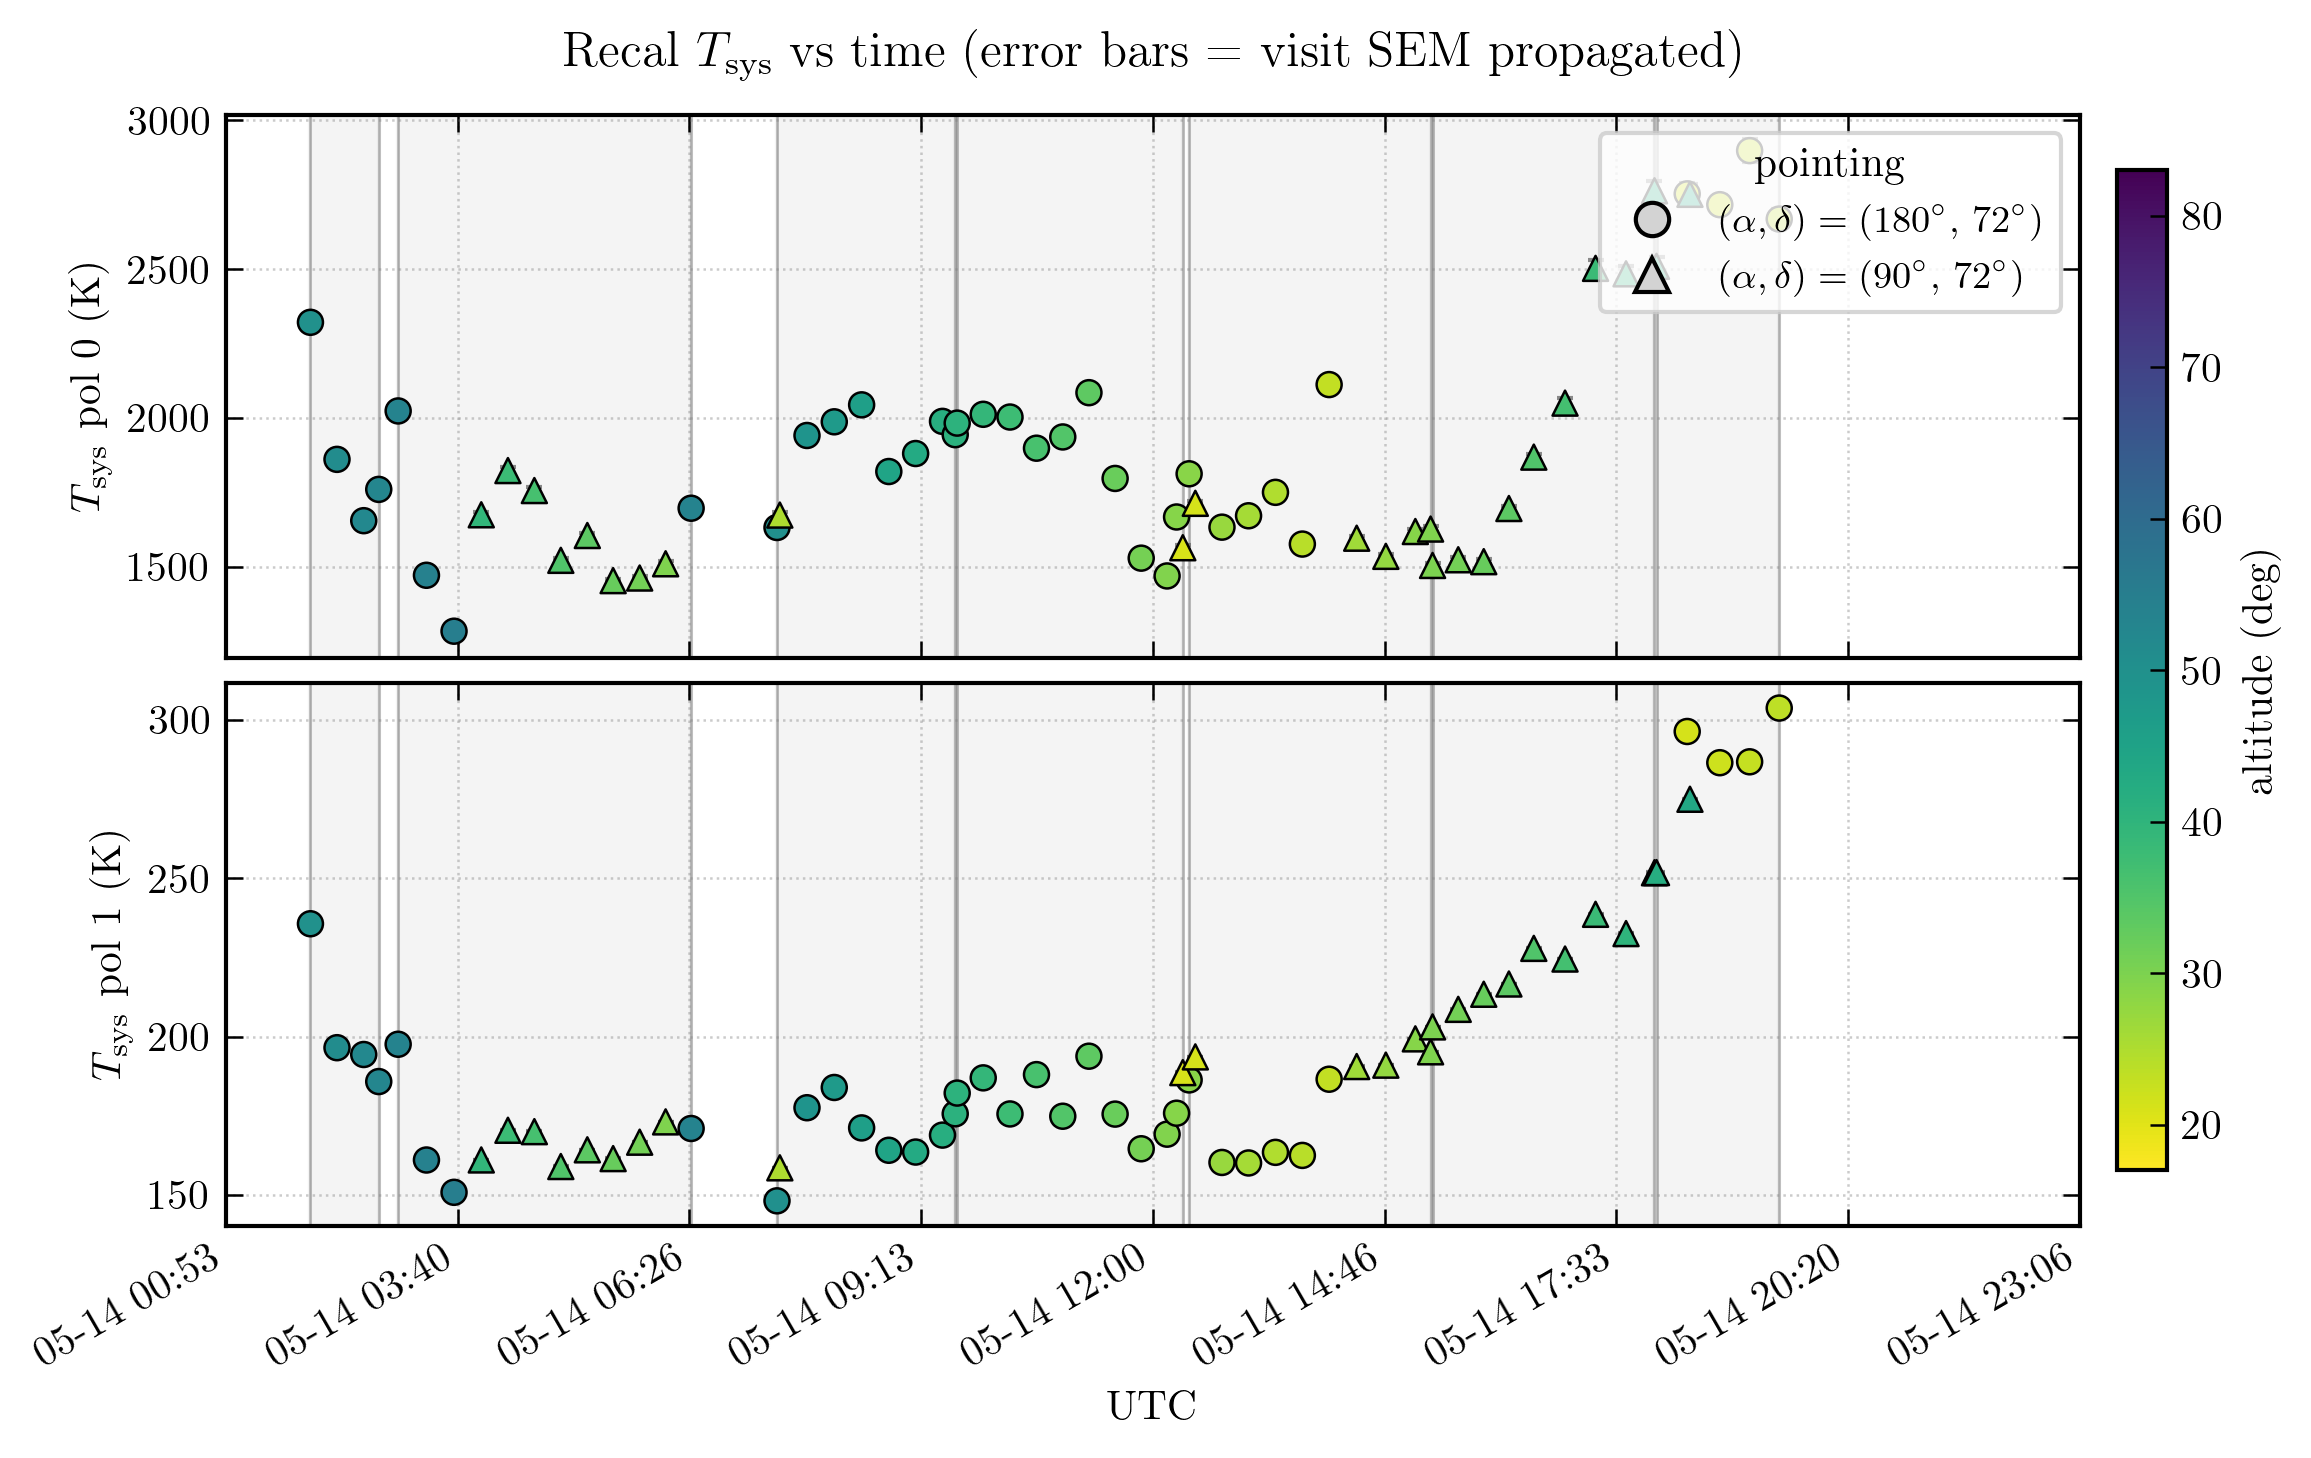

In [5]:
# Two stacked panels (pol 0 and pol 1), session-span shading,
# marker = pointing (circle vs triangle), face colour = altitude.
pointings = sorted(tsys_df['target_id'].unique())
markers = dict(zip(pointings, ['o', '^']))  # recal_drift -> circle, recal_drift_bk -> triangle

sessions = sorted(tsys_df['session'].unique())
session_spans = {
    s: (tsys_df.loc[tsys_df['session'] == s, 't_mid'].min(),
        tsys_df.loc[tsys_df['session'] == s, 't_mid'].max())
    for s in sessions
}

# Anchor colour scale to telescope altitude limits (Leuschner: 17-83 deg).
# Reversed viridis so brighter = lower altitude, darker = higher.
alt_min, alt_max = 17.0, 83.0
cmap = plt.cm.viridis_r

pt_colors = {tid: f'C{i}' for i, tid in enumerate(pointings)}

fig = plt.figure(figsize=(TEXTWIDTH_IN, TEXTWIDTH_IN * 10 / 16),
                 constrained_layout=True)
axes = subpanels(fig, 2, sharex=True)

sc = None
for ax, pol_idx in zip(axes, (0, 1)):
    _shade_sessions(ax, session_spans)
    for tid in pointings:
        sub = tsys_df[(tsys_df['pol'] == pol_idx) & (tsys_df['target_id'] == tid)]
        # SEM error bars (from per-channel propagation, weighted-mean reduced).
        ax.errorbar(sub['t_mid'], sub['tsys'], yerr=sub['sigma_tsys'],
                    fmt='none', ecolor='0.4', elinewidth=LW_FINE,
                    capsize=2, alpha=ALPHA_STANDARD, zorder=2)
        sc = ax.scatter(sub['t_mid'], sub['tsys'], c=sub['alt'],
                        cmap=cmap, vmin=alt_min, vmax=alt_max,
                        marker=markers[tid], s=SS_STANDARD,
                        edgecolor='k', linewidth=LW_FINE, zorder=3)
    ax.set_ylabel(rf'$T_{{\rm sys}}$ pol {pol_idx} (K)')

marker_handles = [
    Line2D([], [], marker=markers[tid], color='none',
           markerfacecolor='lightgray', markeredgecolor='k',
           markersize=8, label=POINTING_LABELS[tid])
    for tid in pointings
]
axes[0].legend(handles=marker_handles, loc='upper right', frameon=True,
               title='pointing')

xticks = axes[1].get_xticks()
axes[1].set_xticks(xticks)
axes[1].set_xticklabels(
    [dt.datetime.fromtimestamp(t, dt.UTC).strftime('%m-%d %H:%M')
     for t in xticks],
    rotation=30, ha='right',
)
axes[1].set_xlabel('UTC')

cbar = fig.colorbar(sc, ax=axes, location='right',
                    fraction=0.04, pad=0.02, shrink=0.9)
cbar.set_label('altitude (deg)')

fig.suptitle(r'Recal $T_{\rm sys}$ vs time (error bars = visit SEM propagated)')
plt.show()

## 4. Per-pol R at recal pointings

The outlier-dump filter was applied in section 2. Here, attach a
per-pol frequency-switched ratio `R_pol(nu)` to every visit, computed
from the visit-averaged noise-off power at LO1 and LO2.


In [6]:
def add_per_pol_R(visits):
    """Attach R_pol(nu) = (P_off_LO1 - P_off_LO2)/P_off_LO2 and its SEM per pol.

    var_R(nu) = (sP1/P2)^2 + (P1 sP2 / P2^2)^2 (partials of R wrt P1, P2).
    """
    for v in visits:
        for pol_idx in (0, 1):
            P1, P2 = v[f'P_off_pol{pol_idx}_lo1'], v[f'P_off_pol{pol_idx}_lo2']
            s1, s2 = v[f'sP_off_pol{pol_idx}_lo1'], v[f'sP_off_pol{pol_idx}_lo2']
            if P1 is None or P2 is None:
                v[f'R_pol{pol_idx}']  = None
                v[f'sR_pol{pol_idx}'] = None
                continue
            with np.errstate(divide='ignore', invalid='ignore'):
                v[f'R_pol{pol_idx}'] = (P1 - P2) / P2
                if s1 is None or s2 is None:
                    v[f'sR_pol{pol_idx}'] = None
                else:
                    var_R = (s1 / P2)**2 + (P1 * s2 / P2**2)**2
                    v[f'sR_pol{pol_idx}'] = np.sqrt(var_R)


add_per_pol_R(gain_visits)
print('Per-pol R and sigma_R attached to all visits.')

Per-pol R and sigma_R attached to all visits.


## 5. Cross-pointing visit pairs (|dt| <= 600 s)

Pair each visit of pointing A with the nearest-in-time visit of
pointing B that is still within `DT_MAX_SEC`. The first chronological
pair becomes the anchor; later pairs serve as consistency checks for
the "diode hasn't drifted between A and B" assumption.


In [7]:
DT_MAX_SEC = 600.0

visits_A = sorted([v for v in gain_visits if v['target_id'] == pointings[0]],
                  key=lambda v: v['t_mid'])
visits_B = sorted([v for v in gain_visits if v['target_id'] == pointings[1]],
                  key=lambda v: v['t_mid'])
print(f'Pointing A ({pointings[0]}): {len(visits_A)} visits')
print(f'Pointing B ({pointings[1]}): {len(visits_B)} visits')

pairs = []
used_B = set()
for vA in visits_A:
    if not visits_B:
        break
    vB = min(visits_B, key=lambda v: abs(v['t_mid'] - vA['t_mid']))
    if abs(vB['t_mid'] - vA['t_mid']) > DT_MAX_SEC:
        continue
    key = (vB['session'], vB['visit_idx'])
    if key in used_B:
        continue
    used_B.add(key)
    pairs.append((vA, vB))

print(f'\n{len(pairs)} cross-pointing pairs within {DT_MAX_SEC:.0f}s')
for i, (vA, vB) in enumerate(pairs[:8]):
    print(f'  {i:2d}: A={dt.datetime.fromtimestamp(vA["t_mid"], dt.UTC):%Y-%m-%d %H:%M}, '
          f'B={dt.datetime.fromtimestamp(vB["t_mid"], dt.UTC):%H:%M}, '
          f'|dt|={abs(vA["t_mid"] - vB["t_mid"]):.0f}s')


Pointing A (recal_drift): 36 visits
Pointing B (recal_drift_bk): 26 visits

4 cross-pointing pairs within 600s
   0: A=2026-05-14 07:29, B=07:31, |dt|=123s
   1: A=2026-05-14 12:16, B=12:21, |dt|=269s
   2: A=2026-05-14 12:26, B=12:30, |dt|=268s
   3: A=2026-05-14 18:24, B=18:26, |dt|=118s


## 6. Anchor solve at t0 (cross-pointing + cross-pol)

First chronological pair `(t0_A, t0_B)` is the anchor:

1. Stipulate `Tcal11A(t0_A, nu) = 100 K` (channel-flat).
2. By time proximity, `Tcal11B(t0_B, nu) = Tcal11A(t0_A, nu)`.
3. `T_sys_11X(nu, t0) = Tcal11X * P_off_11X / (P_on - P_off)_11X` per
   pointing.
4. Cross-pol bridge:
   `T_sys_00X(nu, t0) = T_sys_11X(nu, t0) * R_11X(nu, t0) / R_00X(nu, t0)`.
5. Back-solve `Tcal00X(nu, t0) = T_sys_00X * dP_00X / P_off_00X`.
6. Freeze the per-pointing sky brightness:
   `T_B_X(nu) = T_sys_11X(nu, t0) * R_11X(nu, t0)` -- input to section 9.


In [8]:
TCAL11A_ANCHOR_K = 100.0  # placeholder; refine via known extended-object cal later

anchor_A, anchor_B = pairs[0]
print('Anchor pair (first chronological cross-pointing tie):')
print(f'  A: target={anchor_A["target_id"]}, '
      f't={dt.datetime.fromtimestamp(anchor_A["t_mid"], dt.UTC):%Y-%m-%d %H:%M UTC}')
print(f'  B: target={anchor_B["target_id"]}, '
      f't={dt.datetime.fromtimestamp(anchor_B["t_mid"], dt.UTC):%Y-%m-%d %H:%M UTC}')
print(f'  |dt| = {abs(anchor_A["t_mid"] - anchor_B["t_mid"]):.0f} s')


def visit_mean_P_var(visit, pol_idx, kind):
    """LO-averaged P_kind and its per-channel variance.

    var(P_avg) = sum(var_lo) / N_lo^2 assuming the two LO dumps are
    independent (different RTL-SDR captures).
    """
    pairs_ = [(visit[f'{kind}_pol{pol_idx}_lo{lo}'],
               visit[f's{kind}_pol{pol_idx}_lo{lo}'])
              for lo, _ in LOS]
    pairs_ = [(P, s) for P, s in pairs_ if P is not None]
    if not pairs_:
        return np.full(NFFT, np.nan), np.full(NFFT, np.nan)
    P_avg = np.nanmean(np.stack([P for P, _ in pairs_], axis=0), axis=0)
    if any(s is None for _, s in pairs_):
        return P_avg, np.full(NFFT, np.nan)
    var_stack = np.stack([s**2 for _, s in pairs_], axis=0)
    return P_avg, np.nansum(var_stack, axis=0) / len(pairs_)**2


def visit_mean_P(visit, pol_idx, kind):
    P, _ = visit_mean_P_var(visit, pol_idx, kind)
    return P


def visit_dP_var(visit, pol_idx):
    """LO-averaged (P_on - P_off) and its per-channel variance."""
    P_on,  v_on  = visit_mean_P_var(visit, pol_idx, 'P_on')
    P_off, v_off = visit_mean_P_var(visit, pol_idx, 'P_off')
    return P_on - P_off, v_on + v_off


def visit_dP(visit, pol_idx):
    return visit_dP_var(visit, pol_idx)[0]


# 1-2. Anchor Tcal11 at both pointings (stipulation -> sigma = 0).
Tcal11A_t0 = np.full(NFFT, TCAL11A_ANCHOR_K)
Tcal11B_t0 = Tcal11A_t0.copy()
var_Tcal11_anchor = np.zeros(NFFT)

# Note on independence: in the chain below, P_off enters both R_pol and
# T_sys; strict propagation would carry a covariance term.  We treat
# the channel-level quantities as independent (standard first-order
# Gaussian propagation, common in radiometry).  Off-line channels where
# R is dominated by noise pick up large var_R; the inverse-variance
# weighted scalar reductions downstream automatically downweight them.


def _ratio_var(num, var_num, den, var_den):
    """Variance of num/den from independent num, den (delta method)."""
    with np.errstate(divide='ignore', invalid='ignore'):
        return (var_num / den**2) + (num**2 * var_den / den**4)


# 3. T_sys_11X(nu, t0) = Tcal * P_off / (P_on - P_off).
P_off_11A, var_P_off_11A = visit_mean_P_var(anchor_A, 1, 'P_off')
P_on_11A,  var_P_on_11A  = visit_mean_P_var(anchor_A, 1, 'P_on')
dP_11A,    var_dP_11A    = visit_dP_var(anchor_A, 1)
P_off_11B, var_P_off_11B = visit_mean_P_var(anchor_B, 1, 'P_off')
P_on_11B,  var_P_on_11B  = visit_mean_P_var(anchor_B, 1, 'P_on')
dP_11B,    var_dP_11B    = visit_dP_var(anchor_B, 1)

with np.errstate(divide='ignore', invalid='ignore'):
    T_sys_11A_t0 = Tcal11A_t0 * P_off_11A / dP_11A
    T_sys_11B_t0 = Tcal11B_t0 * P_off_11B / dP_11B
    # Direct propagation through T = Tcal * P_off/(P_on-P_off):
    #   var_T = (Tcal/dP^2)^2 * (P_on^2 var_P_off + P_off^2 var_P_on)
    var_T_sys_11A = (Tcal11A_t0 / dP_11A**2)**2 * (
        P_on_11A**2 * var_P_off_11A + P_off_11A**2 * var_P_on_11A)
    var_T_sys_11B = (Tcal11B_t0 / dP_11B**2)**2 * (
        P_on_11B**2 * var_P_off_11B + P_off_11B**2 * var_P_on_11B)

# 4. Cross-pol bridge -> T_sys_00X(nu, t0) = T_sys_11X * R_11X / R_00X.
R_11A, sR_11A = anchor_A['R_pol1'], anchor_A['sR_pol1']
R_00A, sR_00A = anchor_A['R_pol0'], anchor_A['sR_pol0']
R_11B, sR_11B = anchor_B['R_pol1'], anchor_B['sR_pol1']
R_00B, sR_00B = anchor_B['R_pol0'], anchor_B['sR_pol0']

with np.errstate(divide='ignore', invalid='ignore'):
    T_sys_00A_t0 = T_sys_11A_t0 * R_11A / R_00A
    T_sys_00B_t0 = T_sys_11B_t0 * R_11B / R_00B
    # Three independent factors -> sum of fractional variances.
    rel2_TsA = (var_T_sys_11A / T_sys_11A_t0**2
                + (sR_11A / R_11A)**2 + (sR_00A / R_00A)**2)
    rel2_TsB = (var_T_sys_11B / T_sys_11B_t0**2
                + (sR_11B / R_11B)**2 + (sR_00B / R_00B)**2)
    var_T_sys_00A = T_sys_00A_t0**2 * rel2_TsA
    var_T_sys_00B = T_sys_00B_t0**2 * rel2_TsB

# 5. Tcal00X(nu, t0) = T_sys_00X * dP_00 / P_off_00.
P_off_00A, var_P_off_00A = visit_mean_P_var(anchor_A, 0, 'P_off')
P_on_00A,  var_P_on_00A  = visit_mean_P_var(anchor_A, 0, 'P_on')
dP_00A,    var_dP_00A    = visit_dP_var(anchor_A, 0)
P_off_00B, var_P_off_00B = visit_mean_P_var(anchor_B, 0, 'P_off')
P_on_00B,  var_P_on_00B  = visit_mean_P_var(anchor_B, 0, 'P_on')
dP_00B,    var_dP_00B    = visit_dP_var(anchor_B, 0)

with np.errstate(divide='ignore', invalid='ignore'):
    Tcal00A_t0 = T_sys_00A_t0 * dP_00A / P_off_00A
    Tcal00B_t0 = T_sys_00B_t0 * dP_00B / P_off_00B
    # Independent-factor approximation (dP, P_off share P_off; small bias).
    rel2_Tcal00A = (var_T_sys_00A / T_sys_00A_t0**2
                    + var_dP_00A / dP_00A**2
                    + var_P_off_00A / P_off_00A**2)
    rel2_Tcal00B = (var_T_sys_00B / T_sys_00B_t0**2
                    + var_dP_00B / dP_00B**2
                    + var_P_off_00B / P_off_00B**2)
    var_Tcal00A = Tcal00A_t0**2 * rel2_Tcal00A
    var_Tcal00B = Tcal00B_t0**2 * rel2_Tcal00B

# 6. T_B_X(nu) = T_sys_11X * R_11X.
with np.errstate(divide='ignore', invalid='ignore'):
    T_B_A = T_sys_11A_t0 * R_11A
    T_B_B = T_sys_11B_t0 * R_11B
    var_T_B_A = T_B_A**2 * (var_T_sys_11A / T_sys_11A_t0**2
                            + (sR_11A / R_11A)**2)
    var_T_B_B = T_B_B**2 * (var_T_sys_11B / T_sys_11B_t0**2
                            + (sR_11B / R_11B)**2)


def _med(arr):
    return float(np.nanmedian(arr[overlap_mask]))


def _med_sig(var):
    """Median of sqrt(var) over overlap (per-channel SEM, channel-wise)."""
    return float(np.nanmedian(np.sqrt(var[overlap_mask])))


print('\nAnchor solve (overlap-band medians, +/- channel-median SEM):')
print(f'  T_sys_11A = {_med(T_sys_11A_t0):7.1f} +/- {_med_sig(var_T_sys_11A):5.2f} K     '
      f'T_sys_11B = {_med(T_sys_11B_t0):7.1f} +/- {_med_sig(var_T_sys_11B):5.2f} K')
print(f'  T_sys_00A = {_med(T_sys_00A_t0):7.1f} +/- {_med_sig(var_T_sys_00A):5.2f} K     '
      f'T_sys_00B = {_med(T_sys_00B_t0):7.1f} +/- {_med_sig(var_T_sys_00B):5.2f} K')
print(f'  Tcal00A   = {_med(Tcal00A_t0):7.1f} +/- {_med_sig(var_Tcal00A):5.2f} K     '
      f'Tcal00B   = {_med(Tcal00B_t0):7.1f} +/- {_med_sig(var_Tcal00B):5.2f} K')
print(f'  T_B_A     = {_med(T_B_A):7.3f} +/- {_med_sig(var_T_B_A):.3f} K     '
      f'T_B_B     = {_med(T_B_B):7.3f} +/- {_med_sig(var_T_B_B):.3f} K')

Anchor pair (first chronological cross-pointing tie):
  A: target=recal_drift, t=2026-05-14 07:29 UTC
  B: target=recal_drift_bk, t=2026-05-14 07:31 UTC
  |dt| = 123 s

Anchor solve (overlap-band medians, +/- channel-median SEM):
  T_sys_11A =   191.9 +/-  2.78 K     T_sys_11B =   208.8 +/-  3.01 K
  T_sys_00A =   379.0 +/- 336.27 K     T_sys_00B =   185.5 +/- 219.37 K
  Tcal00A   =     7.1 +/-  7.82 K     Tcal00B   =     2.9 +/-  4.62 K
  T_B_A     =   4.305 +/- 1.077 K     T_B_B     =   2.951 +/- 1.104 K


/tmp/ipykernel_338154/2978003101.py:24: RuntimeWarning: Mean of empty slice
  P_avg = np.nanmean(np.stack([P for P, _ in pairs_], axis=0), axis=0)


## 7. Propagate `Tcal_pol(nu, t, X)` to all recal visits

Under constant `T_B_X(nu)` at each pointing:

    T_sys_pol(nu, t, X) = T_B_X(nu) / R_pol(nu, t, X)
    Tcal_pol(nu, t, X)  = T_sys_pol(nu, t, X) * dP_pol(nu, t, X)
                          / P_off_pol(nu, t, X)

Result is a full spectrum at every visit time, per pol per pointing.


In [9]:
def propagate(visits, T_B_X, var_T_B_X):
    """Propagate visit-level SEM through T_sys = T_B/R and Tcal = T_sys*dP/P_off.

    T_B_X is frozen at the anchor; its per-channel variance ``var_T_B_X``
    is a common-mode contribution shared by every visit and is included
    here for completeness, but does not affect relative drift in time.
    """
    out = []
    for v in visits:
        rec = {'t_mid': v['t_mid'], 'session': v['session'],
               'target_id': v['target_id'], 'alt': v['alt_mean']}
        for pol_idx in (0, 1):
            R, sR = v[f'R_pol{pol_idx}'], v[f'sR_pol{pol_idx}']
            if R is None:
                rec[f'T_sys_pol{pol_idx}']     = None
                rec[f'var_T_sys_pol{pol_idx}'] = None
                rec[f'Tcal_pol{pol_idx}']      = None
                rec[f'var_Tcal_pol{pol_idx}']  = None
                continue
            P_off, var_P_off = visit_mean_P_var(v, pol_idx, 'P_off')
            dP,    var_dP    = visit_dP_var(v, pol_idx)
            with np.errstate(divide='ignore', invalid='ignore'):
                T_sys = T_B_X / R
                rel2_Tsys = var_T_B_X / T_B_X**2
                if sR is not None:
                    rel2_Tsys = rel2_Tsys + (sR / R)**2
                var_T_sys = T_sys**2 * rel2_Tsys

                Tcal = T_sys * dP / P_off
                rel2_Tcal = (rel2_Tsys
                             + var_dP / dP**2
                             + var_P_off / P_off**2)
                var_Tcal = Tcal**2 * rel2_Tcal

            rec[f'T_sys_pol{pol_idx}']     = T_sys
            rec[f'var_T_sys_pol{pol_idx}'] = var_T_sys
            rec[f'Tcal_pol{pol_idx}']      = Tcal
            rec[f'var_Tcal_pol{pol_idx}']  = var_Tcal
        out.append(rec)
    return out


tcal_A_series = propagate(visits_A, T_B_A, var_T_B_A)
tcal_B_series = propagate(visits_B, T_B_B, var_T_B_B)
print(f'Propagated: {len(tcal_A_series)} A visits, '
      f'{len(tcal_B_series)} B visits.')

Propagated: 36 A visits, 26 B visits.


/tmp/ipykernel_338154/2978003101.py:24: RuntimeWarning: Mean of empty slice
  P_avg = np.nanmean(np.stack([P for P, _ in pairs_], axis=0), axis=0)


## 8. `Tcal{00,11}{A,B}(t)` at the HI peak channel

Pick a single characteristic channel for the time-series view: the
channel where `R_11A(nu)` at the anchor visit is largest within the
overlap band -- the HI line emission peak. Each pol panel shows the
four Tcal time series (pointings A and B). Horizontal dashed lines
mark the anchor's Tcal value at this channel per pointing; vertical
dotted lines mark the anchor visit times.


HI characteristic channel: ch 666, f = 1420.3412 MHz, R_11A(anchor) = 0.0510, T_B_A = 9.66 K


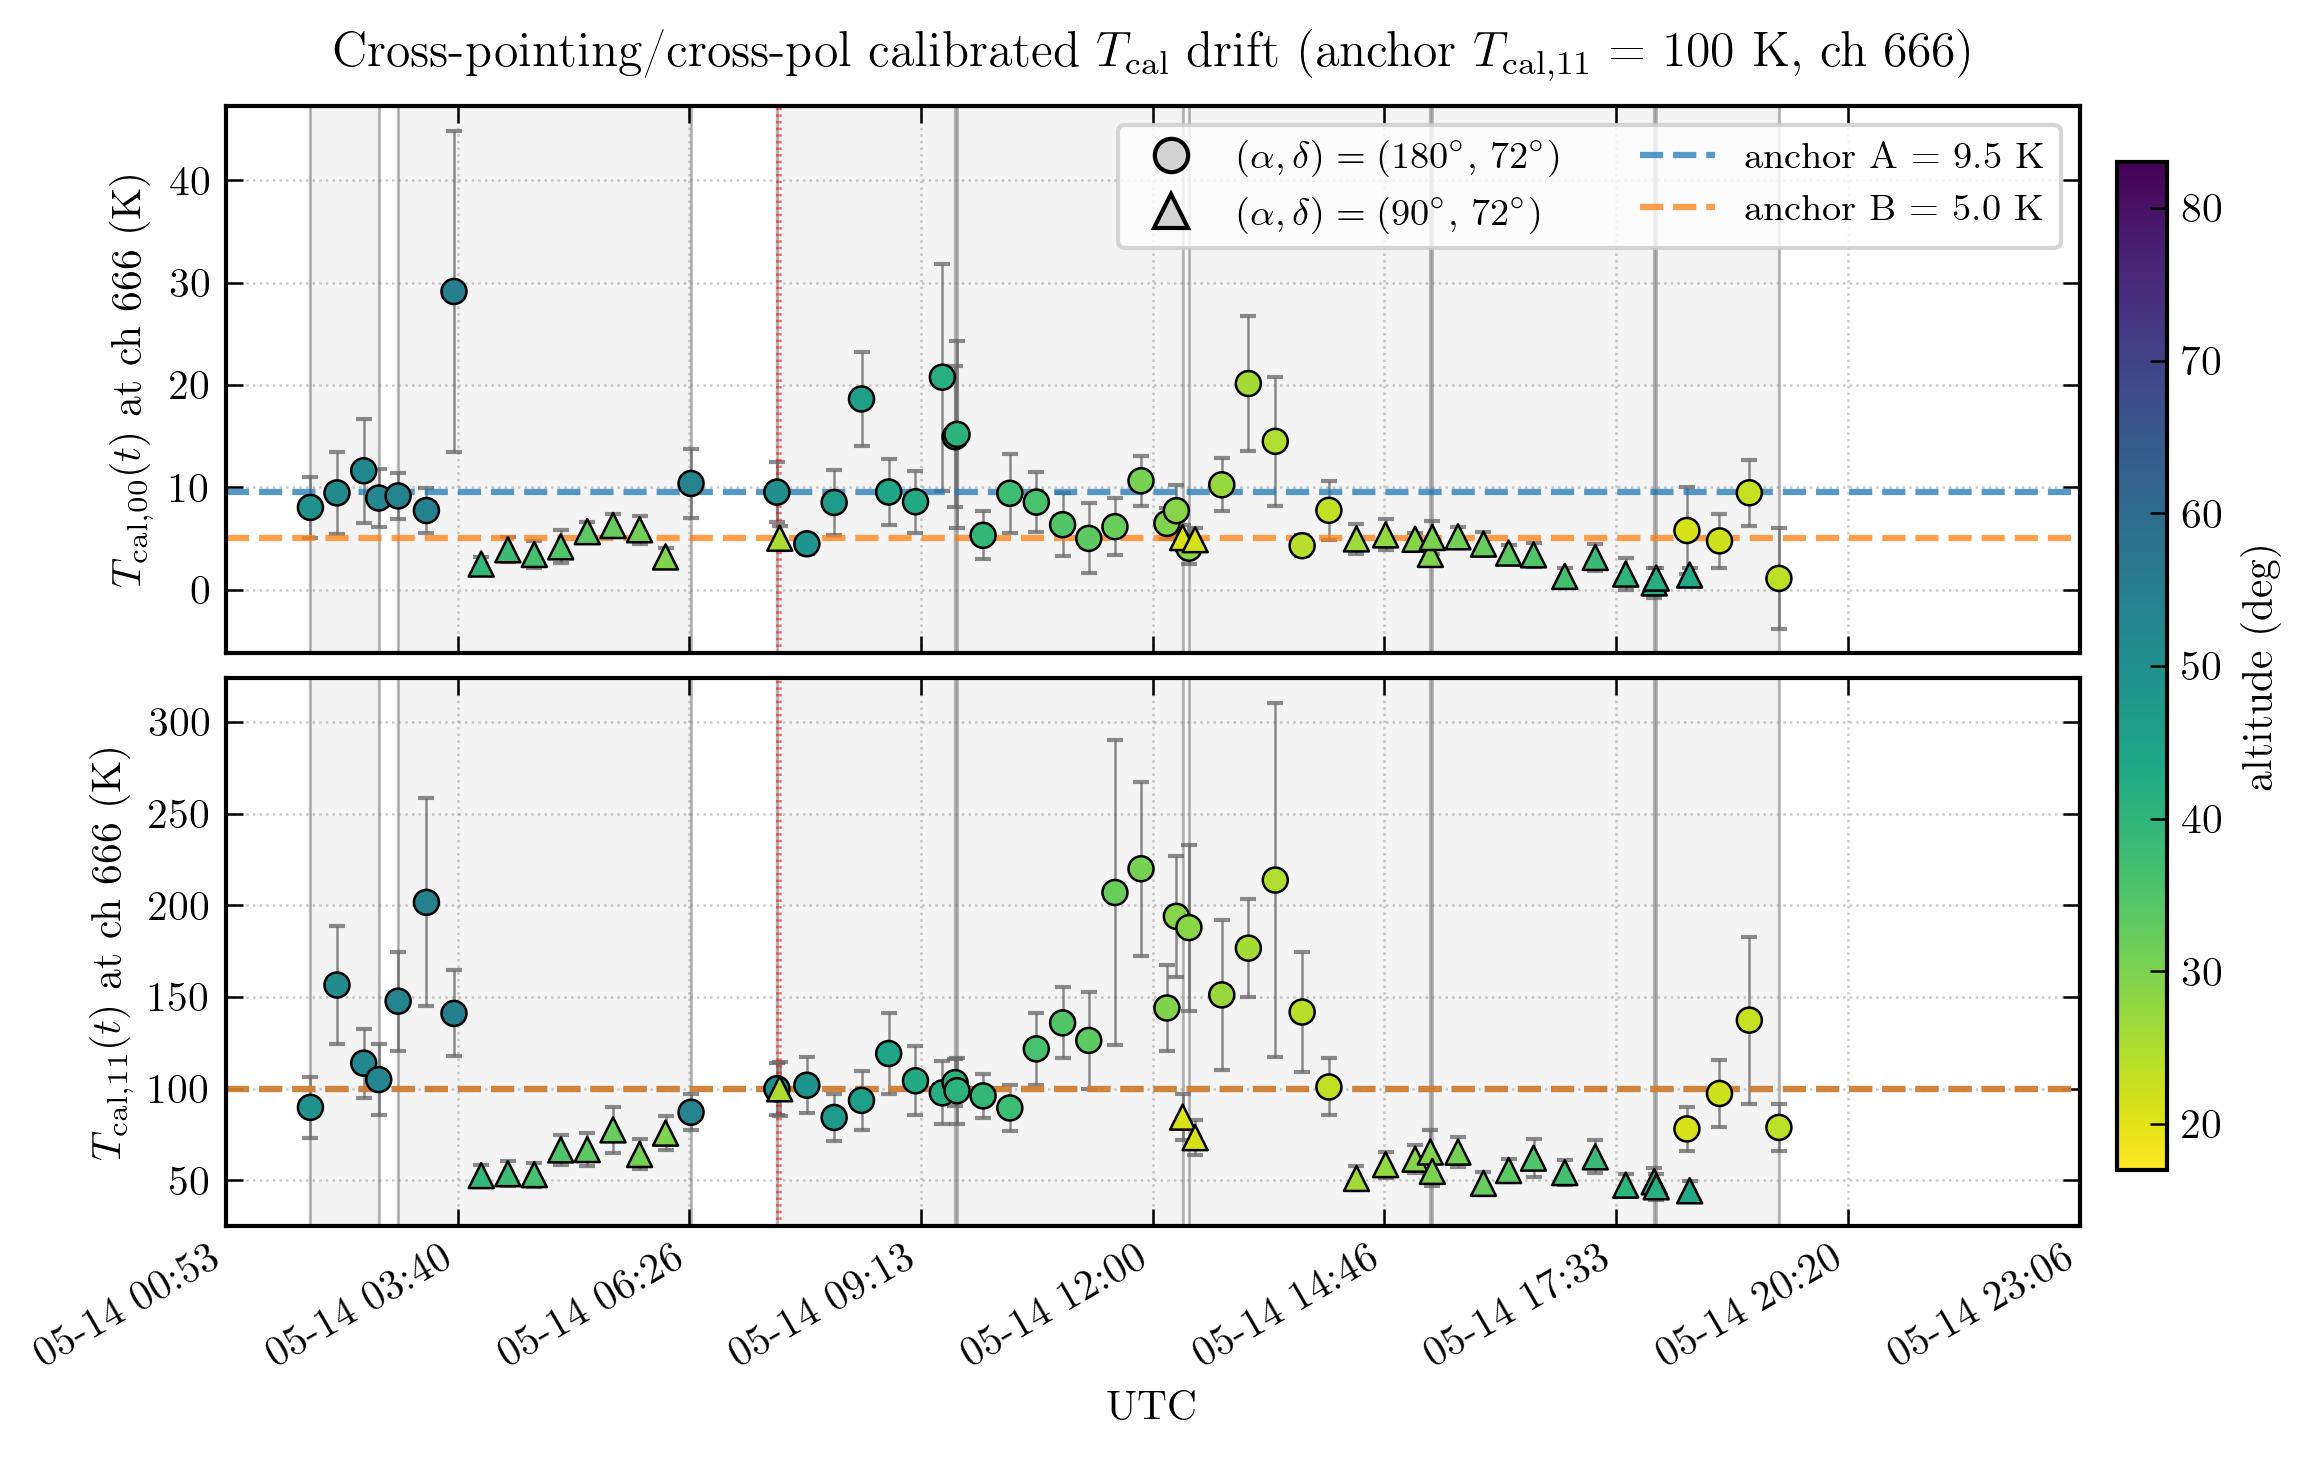

In [10]:
overlap_idx = np.where(overlap_mask)[0]
# Avoid the DC bin when picking the peak.
R_for_peak = anchor_A['R_pol1'].copy()
R_for_peak[NFFT // 2] = np.nan
peak_local = int(np.nanargmax(R_for_peak[overlap_mask]))
HI_CHANNEL = int(overlap_idx[peak_local])
print(f'HI characteristic channel: ch {HI_CHANNEL}, '
      f'f = {grid["f_overlap"][peak_local]:.4f} MHz, '
      f'R_11A(anchor) = {R_for_peak[HI_CHANNEL]:.4f}, '
      f'T_B_A = {T_B_A[HI_CHANNEL]:.2f} K')


def df_at_channel(series, ch):
    rows = []
    for r in series:
        row = {'t_mid': r['t_mid'], 'session': r['session'],
               'target_id': r['target_id'], 'alt': r['alt']}
        for pol_idx in (0, 1):
            T = r[f'Tcal_pol{pol_idx}']
            V = r[f'var_Tcal_pol{pol_idx}']
            row[f'Tcal_pol{pol_idx}']  = (float(T[ch]) if T is not None
                                           else np.nan)
            row[f'sigma_Tcal_pol{pol_idx}'] = (float(np.sqrt(V[ch]))
                                                if V is not None else np.nan)
        rows.append(row)
    return pd.DataFrame(rows)


dfA = df_at_channel(tcal_A_series, HI_CHANNEL)
dfB = df_at_channel(tcal_B_series, HI_CHANNEL)
anchor_vals = {
    0: (float(Tcal00A_t0[HI_CHANNEL]), float(Tcal00B_t0[HI_CHANNEL])),
    1: (float(Tcal11A_t0[HI_CHANNEL]), float(Tcal11B_t0[HI_CHANNEL])),
}

fig = plt.figure(figsize=(TEXTWIDTH_IN, TEXTWIDTH_IN * 10 / 16),
                 constrained_layout=True)
axes = subpanels(fig, 2, sharex=True)

sc = None
for ax, pol_idx in zip(axes, (0, 1)):
    _shade_sessions(ax, session_spans)
    for tid, df_pt in zip(pointings, (dfA, dfB)):
        ax.errorbar(df_pt['t_mid'], df_pt[f'Tcal_pol{pol_idx}'],
                    yerr=df_pt[f'sigma_Tcal_pol{pol_idx}'],
                    fmt='none', ecolor='0.4', elinewidth=LW_FINE,
                    capsize=2, alpha=ALPHA_STANDARD, zorder=2)
        sc = ax.scatter(df_pt['t_mid'], df_pt[f'Tcal_pol{pol_idx}'],
                        c=df_pt['alt'], cmap=cmap,
                        vmin=alt_min, vmax=alt_max,
                        marker=markers[tid], s=SS_STANDARD,
                        edgecolor='k', linewidth=LW_FINE, zorder=3)
    ax.axhline(anchor_vals[pol_idx][0], color=pt_colors[pointings[0]],
               **MODEL_STYLE,
               label=f'anchor A = {anchor_vals[pol_idx][0]:.1f} K')
    ax.axhline(anchor_vals[pol_idx][1], color=pt_colors[pointings[1]],
               **MODEL_STYLE,
               label=f'anchor B = {anchor_vals[pol_idx][1]:.1f} K')
    ax.axvline(anchor_A['t_mid'], color='red', lw=LW_FINE, ls=':',
               alpha=ALPHA_LIGHT)
    ax.axvline(anchor_B['t_mid'], color='red', lw=LW_FINE, ls=':',
               alpha=ALPHA_LIGHT)
    ax.set_ylabel(
        rf'$T_{{\rm cal,{pol_idx}{pol_idx}}}(t)$ at ch {HI_CHANNEL} (K)'
    )

marker_handles = [
    Line2D([], [], marker=markers[tid], color='none',
           markerfacecolor='lightgray', markeredgecolor='k',
           markersize=8, label=POINTING_LABELS[tid])
    for tid in pointings
]
axes[0].legend(handles=(marker_handles
                        + axes[0].get_legend_handles_labels()[0]),
               loc='upper right', frameon=True, ncol=2)

xticks = axes[1].get_xticks()
axes[1].set_xticks(xticks)
axes[1].set_xticklabels(
    [dt.datetime.fromtimestamp(t, dt.UTC).strftime('%m-%d %H:%M')
     for t in xticks],
    rotation=30, ha='right',
)
axes[1].set_xlabel('UTC')

cbar = fig.colorbar(sc, ax=axes, location='right',
                    fraction=0.04, pad=0.02, shrink=0.9)
cbar.set_label('altitude (deg)')

fig.suptitle(
    rf'Cross-pointing/cross-pol calibrated $T_{{\rm cal}}$ drift '
    rf'(anchor $T_{{\rm cal,11}}$ = {TCAL11A_ANCHOR_K:.0f} K, '
    rf'ch {HI_CHANNEL})'
)
plt.show()

## 9. Integrated-band track (scalar drift)

Section 7 divided by `R_pol(nu, t, X)`, which is essentially noise
outside the HI line. Here we integrate `R` over the **full usable
overlap bandwidth** (the LO1/LO2 sky-frequency overlap, DC bin
excluded; RFI-flagged channels propagate as NaN and drop out of the
sum). The same fixed channel mask is used for every visit so the
comparison is apples-to-apples; the chain collapses to one scalar per
`(visit, pol, pointing)`:

    W_R_pol(t, X) = sum over INT_MASK of R_pol(nu, t, X)
    <P_off>, <dP>   = band-averaged power over INT_MASK
    T_sys_pol(t, X) = W_T_X / W_R_pol(t, X)
    Tcal_pol(t, X)  = T_sys_pol(t, X) * <dP_pol> / <P_off_pol>

where `W_T_X` is the integrated `R * T_sys` frozen at the anchor.
Trade-off vs a narrow line window: more channels integrated => off-line
noise contributes, but no arbitrary window choice and the result is
just a band-averaged scalar.


Integration mask: 449 channels (1419.796 - 1421.201 MHz, DC excluded)


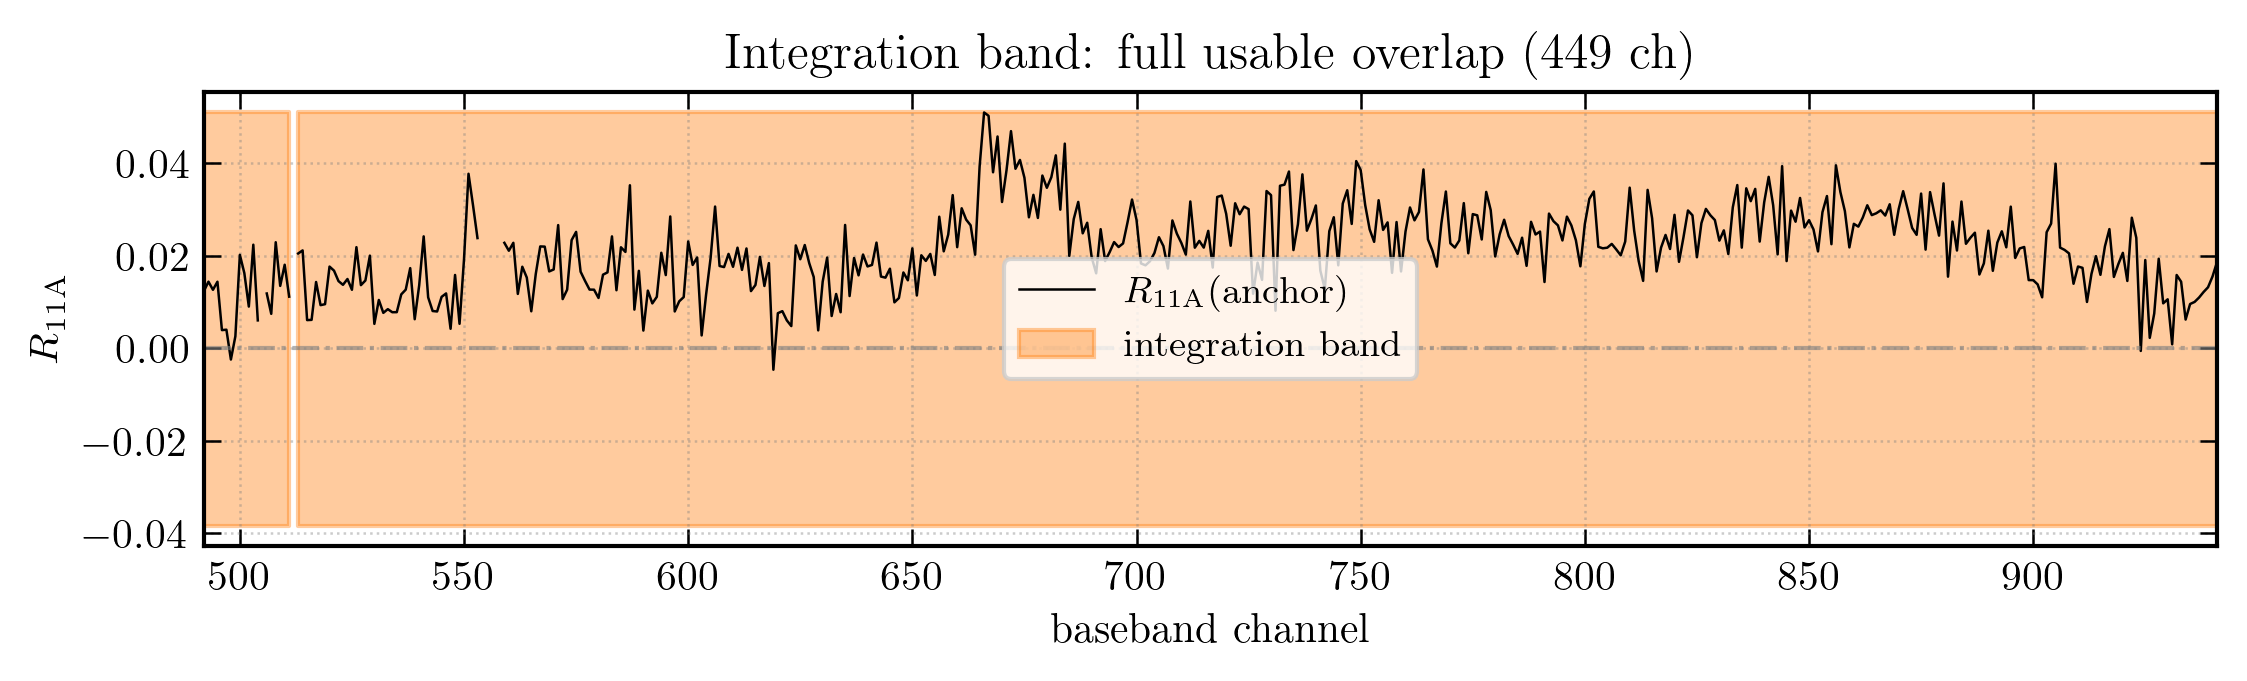

In [11]:
# Integration mask = full usable overlap bandwidth, DC excluded.
# RFI-flagged channels in any visit's R_pol propagate as NaN and drop out
# of the np.nansum below; the mask itself is constant.

INT_MASK = overlap_mask.copy()
INT_MASK[NFFT // 2] = False  # DC bin

print(f'Integration mask: {INT_MASK.sum()} channels '
      f'({grid["f_overlap_lo"]:.3f} - {grid["f_overlap_hi"]:.3f} MHz, DC excluded)')

ch_axis = np.arange(NFFT)
R_anchor = anchor_A['R_pol1'].copy()
R_anchor[NFFT // 2] = np.nan
r_lo, r_hi = np.nanmin(R_anchor), np.nanmax(R_anchor)

fig, ax = textwidth_figure(5)
ax.plot(ch_axis, R_anchor, lw=LW_FINE, color='k',
        label=r'$R_{11{\rm A}}(\mathrm{anchor})$')
ax.fill_between(ch_axis, r_lo, r_hi, where=INT_MASK,
                color='C1', alpha=ALPHA_FAINT,
                label='integration band')
zero_line(ax)
overlap_idx_full = np.where(overlap_mask)[0]
ax.set_xlim(overlap_idx_full[0], overlap_idx_full[-1])
ax.set_xlabel('baseband channel')
ax.set_ylabel(r'$R_{11{\rm A}}$')
ax.set_title(f'Integration band: full usable overlap ({INT_MASK.sum()} ch)')
ax.legend(loc='best')
plt.show()


In [12]:
# Scalar reductions over the fixed integration mask, with per-step
# error propagation from visit-mean SEMs.

def W_R_visit_var(visit, pol_idx, mask):
    """sum_{mask} R_pol and its variance from per-channel SEMs."""
    R, sR = visit[f'R_pol{pol_idx}'], visit[f'sR_pol{pol_idx}']
    if R is None:
        return np.nan, np.nan
    good = mask & np.isfinite(R)
    wr = float(np.nansum(R[good]))
    if sR is None:
        return wr, np.nan
    return wr, float(np.nansum((sR[good])**2))


def W_R_visit(visit, pol_idx, mask):
    return W_R_visit_var(visit, pol_idx, mask)[0]


def bandavg_P_var(visit, pol_idx, kind, mask):
    """Band-averaged P (LOs combined) and the variance of that scalar mean."""
    P_avg, var_avg = visit_mean_P_var(visit, pol_idx, kind)
    Pm, Vm = P_avg[mask], var_avg[mask]
    good = np.isfinite(Pm) & np.isfinite(Vm)
    if not np.any(good):
        return np.nan, np.nan
    N = int(good.sum())
    return float(np.mean(Pm[good])), float(np.sum(Vm[good]) / N**2)


def bandavg_P(visit, pol_idx, kind, mask):
    return bandavg_P_var(visit, pol_idx, kind, mask)[0]


def bandavg_dP_var(visit, pol_idx, mask):
    Pon,  vPon  = bandavg_P_var(visit, pol_idx, 'P_on',  mask)
    Poff, vPoff = bandavg_P_var(visit, pol_idx, 'P_off', mask)
    return Pon - Poff, vPon + vPoff


def bandavg_dP(visit, pol_idx, mask):
    return bandavg_dP_var(visit, pol_idx, mask)[0]


# Anchor solve (scalar form, with propagated variances).
WR_11A_t0, var_WR_11A_t0 = W_R_visit_var(anchor_A, 1, INT_MASK)
WR_00A_t0, var_WR_00A_t0 = W_R_visit_var(anchor_A, 0, INT_MASK)
WR_11B_t0, var_WR_11B_t0 = W_R_visit_var(anchor_B, 1, INT_MASK)
WR_00B_t0, var_WR_00B_t0 = W_R_visit_var(anchor_B, 0, INT_MASK)

Pm_off_11A, vPm_off_11A = bandavg_P_var(anchor_A, 1, 'P_off', INT_MASK)
Pm_on_11A,  vPm_on_11A  = bandavg_P_var(anchor_A, 1, 'P_on',  INT_MASK)
dPm_11A,    vdPm_11A    = bandavg_dP_var(anchor_A, 1, INT_MASK)
Pm_off_11B, vPm_off_11B = bandavg_P_var(anchor_B, 1, 'P_off', INT_MASK)
Pm_on_11B,  vPm_on_11B  = bandavg_P_var(anchor_B, 1, 'P_on',  INT_MASK)
dPm_11B,    vdPm_11B    = bandavg_dP_var(anchor_B, 1, INT_MASK)

T_sys_11A_t0_s = TCAL11A_ANCHOR_K * Pm_off_11A / dPm_11A
T_sys_11B_t0_s = TCAL11A_ANCHOR_K * Pm_off_11B / dPm_11B
var_T_sys_11A_t0_s = (TCAL11A_ANCHOR_K / dPm_11A**2)**2 * (
    Pm_on_11A**2 * vPm_off_11A + Pm_off_11A**2 * vPm_on_11A)
var_T_sys_11B_t0_s = (TCAL11A_ANCHOR_K / dPm_11B**2)**2 * (
    Pm_on_11B**2 * vPm_off_11B + Pm_off_11B**2 * vPm_on_11B)

# T_sys_00 = T_sys_11 * WR_11 / WR_00
T_sys_00A_t0_s = T_sys_11A_t0_s * WR_11A_t0 / WR_00A_t0
T_sys_00B_t0_s = T_sys_11B_t0_s * WR_11B_t0 / WR_00B_t0
rel2_Ts00A = (var_T_sys_11A_t0_s / T_sys_11A_t0_s**2
              + var_WR_11A_t0 / WR_11A_t0**2
              + var_WR_00A_t0 / WR_00A_t0**2)
rel2_Ts00B = (var_T_sys_11B_t0_s / T_sys_11B_t0_s**2
              + var_WR_11B_t0 / WR_11B_t0**2
              + var_WR_00B_t0 / WR_00B_t0**2)
var_T_sys_00A_t0_s = T_sys_00A_t0_s**2 * rel2_Ts00A
var_T_sys_00B_t0_s = T_sys_00B_t0_s**2 * rel2_Ts00B

# Tcal_00 anchor = T_sys_00 * <dP_00> / <P_off_00>
Pm_off_00A, vPm_off_00A = bandavg_P_var(anchor_A, 0, 'P_off', INT_MASK)
dPm_00A,    vdPm_00A    = bandavg_dP_var(anchor_A, 0, INT_MASK)
Pm_off_00B, vPm_off_00B = bandavg_P_var(anchor_B, 0, 'P_off', INT_MASK)
dPm_00B,    vdPm_00B    = bandavg_dP_var(anchor_B, 0, INT_MASK)

Tcal00A_t0_s = T_sys_00A_t0_s * dPm_00A / Pm_off_00A
Tcal00B_t0_s = T_sys_00B_t0_s * dPm_00B / Pm_off_00B
var_Tcal00A_t0_s = Tcal00A_t0_s**2 * (rel2_Ts00A
                                       + vdPm_00A / dPm_00A**2
                                       + vPm_off_00A / Pm_off_00A**2)
var_Tcal00B_t0_s = Tcal00B_t0_s**2 * (rel2_Ts00B
                                       + vdPm_00B / dPm_00B**2
                                       + vPm_off_00B / Pm_off_00B**2)

# Frozen W_T_X = T_sys_11 * WR_11 (carries anchor uncertainty; common-mode
# for downstream drift, so its variance does not move points relative to
# each other, only the overall scale).
W_T_A = T_sys_11A_t0_s * WR_11A_t0
W_T_B = T_sys_11B_t0_s * WR_11B_t0
var_W_T_A = W_T_A**2 * (var_T_sys_11A_t0_s / T_sys_11A_t0_s**2
                        + var_WR_11A_t0 / WR_11A_t0**2)
var_W_T_B = W_T_B**2 * (var_T_sys_11B_t0_s / T_sys_11B_t0_s**2
                        + var_WR_11B_t0 / WR_11B_t0**2)


def _s(v):
    return float(np.sqrt(v))


print('Scalar anchor solve (integrated over usable overlap):')
print(f'  T_sys_11A = {T_sys_11A_t0_s:7.1f} +/- {_s(var_T_sys_11A_t0_s):5.2f} K     '
      f'T_sys_11B = {T_sys_11B_t0_s:7.1f} +/- {_s(var_T_sys_11B_t0_s):5.2f} K')
print(f'  T_sys_00A = {T_sys_00A_t0_s:7.1f} +/- {_s(var_T_sys_00A_t0_s):5.2f} K     '
      f'T_sys_00B = {T_sys_00B_t0_s:7.1f} +/- {_s(var_T_sys_00B_t0_s):5.2f} K')
print(f'  Tcal00A   = {Tcal00A_t0_s:7.1f} +/- {_s(var_Tcal00A_t0_s):5.2f} K     '
      f'Tcal00B   = {Tcal00B_t0_s:7.1f} +/- {_s(var_Tcal00B_t0_s):5.2f} K')
print(f'  W_T_A     = {W_T_A:8.3g} +/- {_s(var_W_T_A):.2g}     '
      f'W_T_B     = {W_T_B:8.3g} +/- {_s(var_W_T_B):.2g}')


def propagate_scalar(visits, W_T_X, var_W_T_X):
    """Per-visit scalar Tcal_pol with propagated SEM."""
    rows = []
    for v in visits:
        row = {'t_mid': v['t_mid'], 'session': v['session'],
               'target_id': v['target_id'], 'alt': v['alt_mean']}
        for pol_idx in (0, 1):
            wr, var_wr = W_R_visit_var(v, pol_idx, INT_MASK)
            if not np.isfinite(wr) or wr == 0:
                row[f'T_sys_pol{pol_idx}']        = np.nan
                row[f'sigma_T_sys_pol{pol_idx}']  = np.nan
                row[f'Tcal_pol{pol_idx}']         = np.nan
                row[f'sigma_Tcal_pol{pol_idx}']   = np.nan
                continue
            T_sys = W_T_X / wr
            rel2_Tsys = var_W_T_X / W_T_X**2 + var_wr / wr**2
            var_Tsys = T_sys**2 * rel2_Tsys

            Pm,  vPm  = bandavg_P_var(v, pol_idx, 'P_off', INT_MASK)
            dPm, vdPm = bandavg_dP_var(v, pol_idx, INT_MASK)
            Tcal = T_sys * dPm / Pm
            var_Tcal = Tcal**2 * (rel2_Tsys + vdPm / dPm**2 + vPm / Pm**2)

            row[f'T_sys_pol{pol_idx}']       = T_sys
            row[f'sigma_T_sys_pol{pol_idx}'] = float(np.sqrt(var_Tsys))
            row[f'Tcal_pol{pol_idx}']        = Tcal
            row[f'sigma_Tcal_pol{pol_idx}']  = float(np.sqrt(var_Tcal))
        rows.append(row)
    return pd.DataFrame(rows)


dfA_s = propagate_scalar(visits_A, W_T_A, var_W_T_A)
dfB_s = propagate_scalar(visits_B, W_T_B, var_W_T_B)
print(f'\nPropagated scalar Tcal: {len(dfA_s)} A visits, {len(dfB_s)} B visits.')

Scalar anchor solve (integrated over usable overlap):
  T_sys_11A =   189.1 +/-  0.14 K     T_sys_11B =   204.2 +/-  0.16 K
  T_sys_00A =   690.4 +/- 32.13 K     T_sys_00B =   317.1 +/-  8.21 K
  Tcal00A   =    18.1 +/-  0.86 K     Tcal00B   =     7.8 +/-  0.22 K
  W_T_A     = 1.82e+03 +/- 23     W_T_B     = 1.74e+03 +/- 24

Propagated scalar Tcal: 36 A visits, 26 B visits.


/tmp/ipykernel_338154/2978003101.py:24: RuntimeWarning: Mean of empty slice
  P_avg = np.nanmean(np.stack([P for P, _ in pairs_], axis=0), axis=0)


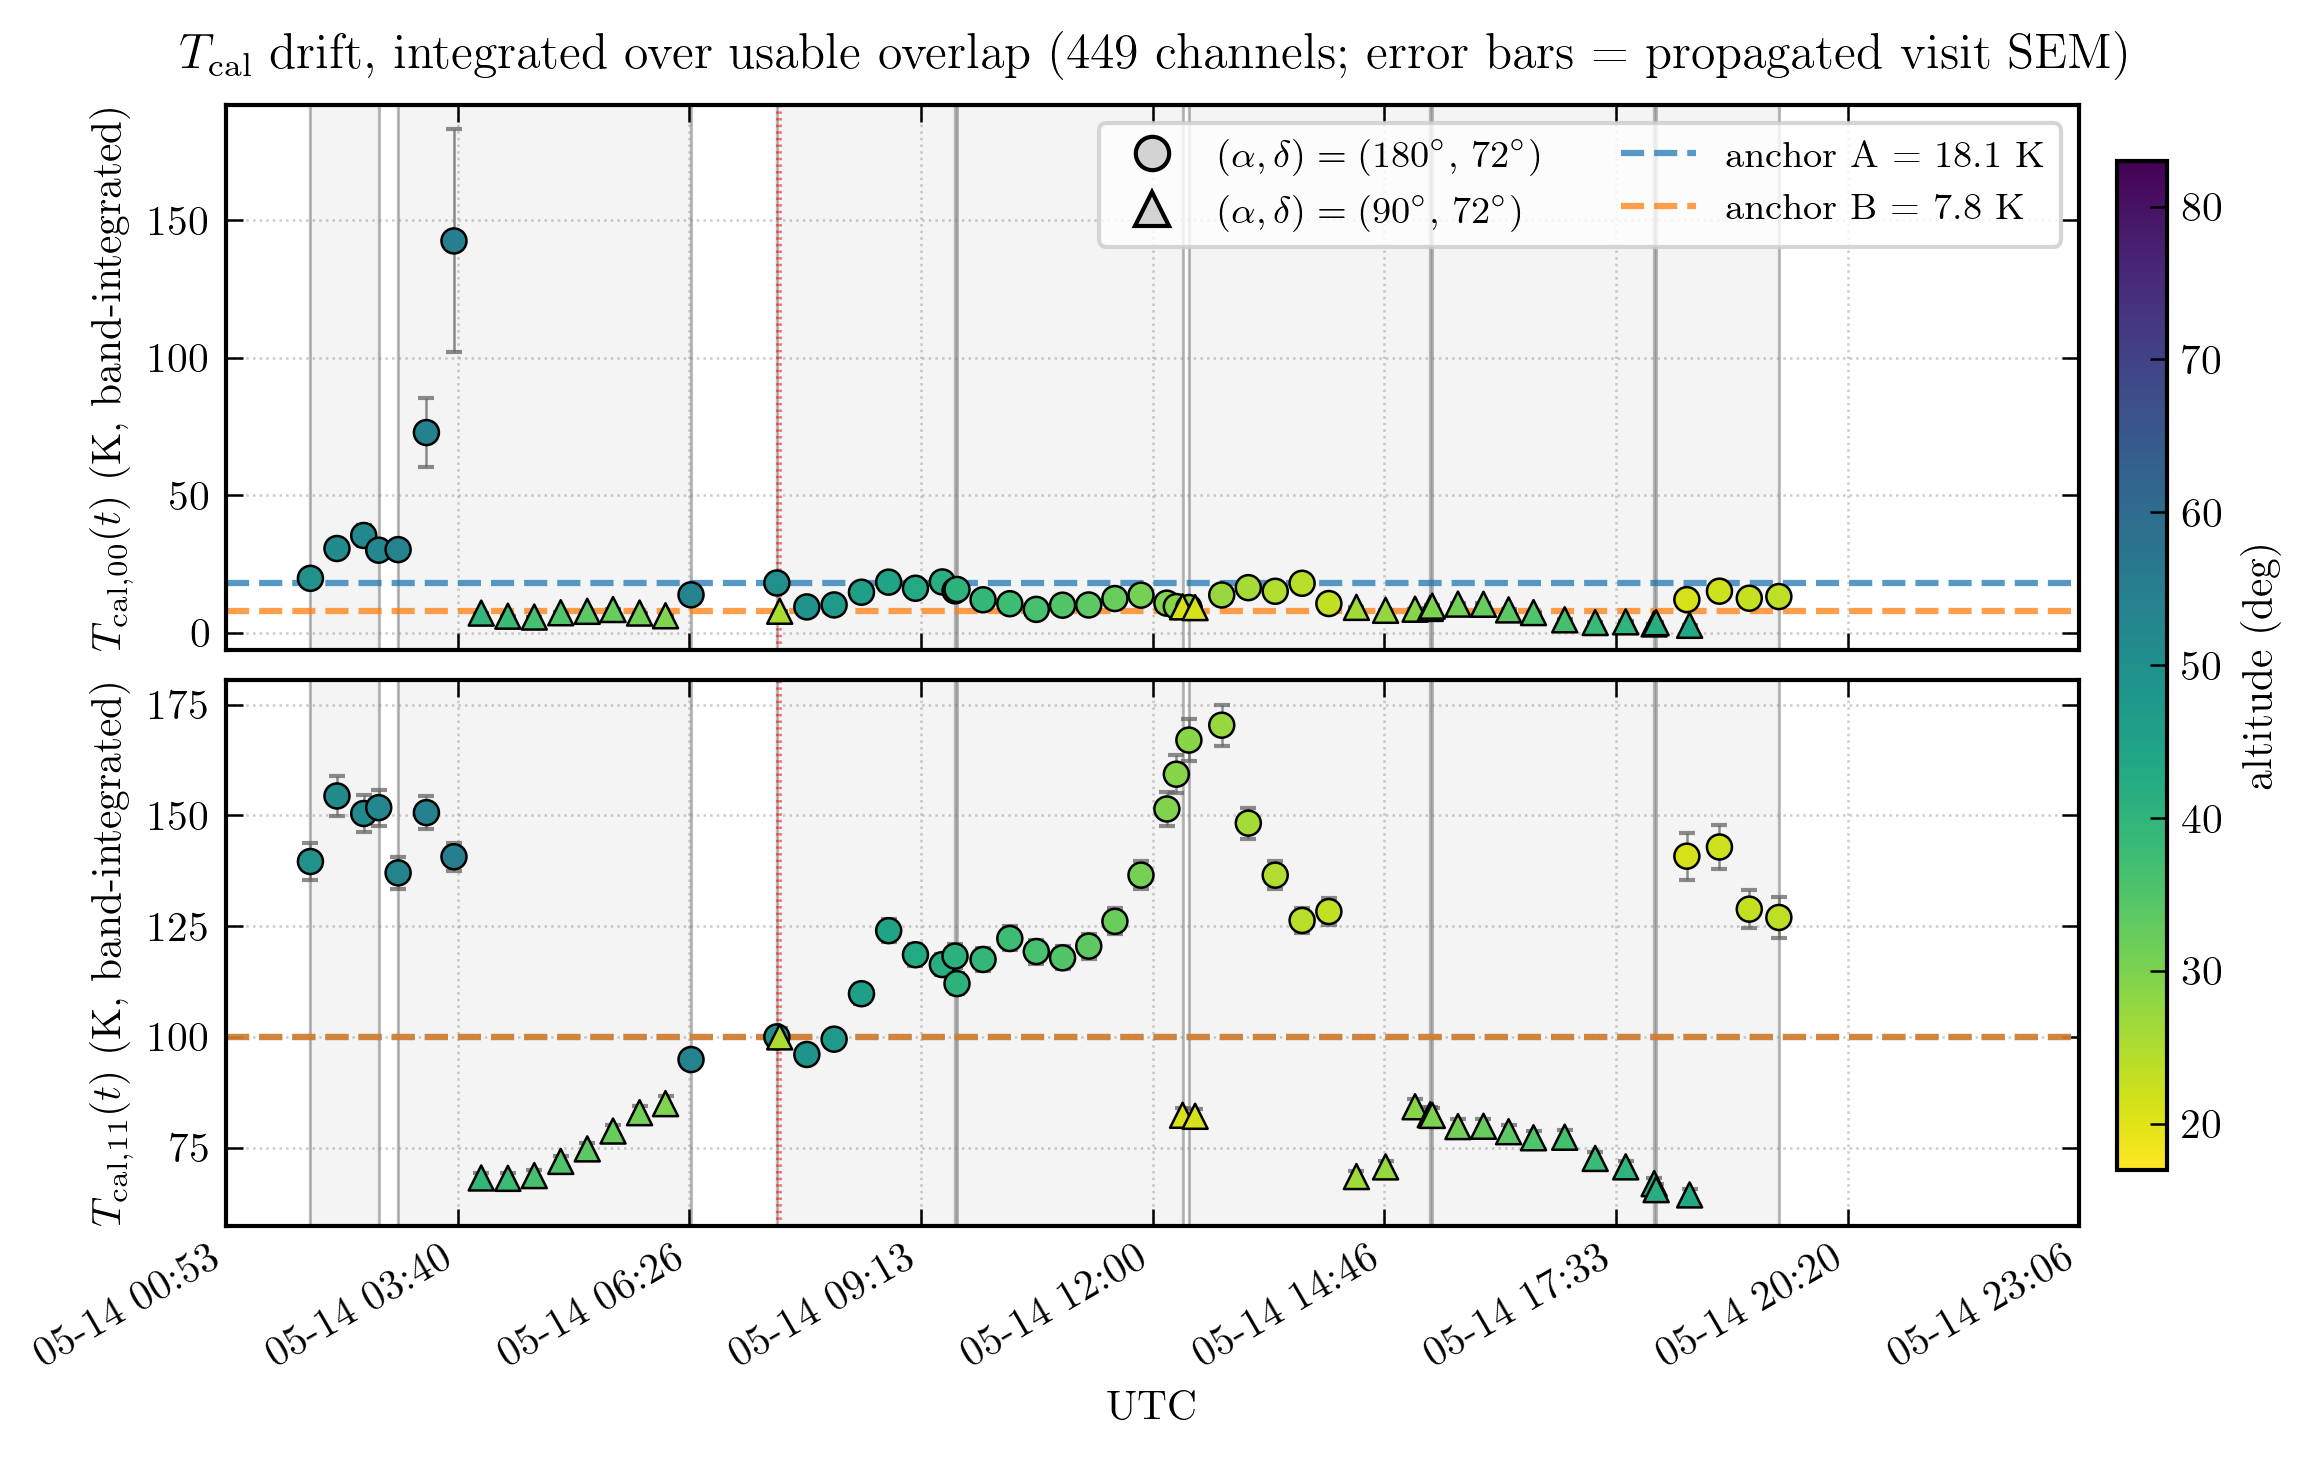

In [13]:
anchor_vals_s = {
    0: (Tcal00A_t0_s, Tcal00B_t0_s),
    1: (TCAL11A_ANCHOR_K, TCAL11A_ANCHOR_K),
}

fig = plt.figure(figsize=(TEXTWIDTH_IN, TEXTWIDTH_IN * 10 / 16),
                 constrained_layout=True)
axes = subpanels(fig, 2, sharex=True)

sc = None
for ax, pol_idx in zip(axes, (0, 1)):
    _shade_sessions(ax, session_spans)
    for tid, df_pt in zip(pointings, (dfA_s, dfB_s)):
        ax.errorbar(df_pt['t_mid'], df_pt[f'Tcal_pol{pol_idx}'],
                    yerr=df_pt[f'sigma_Tcal_pol{pol_idx}'],
                    fmt='none', ecolor='0.4', elinewidth=LW_FINE,
                    capsize=2, alpha=ALPHA_STANDARD, zorder=2)
        sc = ax.scatter(df_pt['t_mid'], df_pt[f'Tcal_pol{pol_idx}'],
                        c=df_pt['alt'], cmap=cmap,
                        vmin=alt_min, vmax=alt_max,
                        marker=markers[tid], s=SS_STANDARD,
                        edgecolor='k', linewidth=LW_FINE, zorder=3)
    ax.axhline(anchor_vals_s[pol_idx][0], color=pt_colors[pointings[0]],
               **MODEL_STYLE,
               label=f'anchor A = {anchor_vals_s[pol_idx][0]:.1f} K')
    ax.axhline(anchor_vals_s[pol_idx][1], color=pt_colors[pointings[1]],
               **MODEL_STYLE,
               label=f'anchor B = {anchor_vals_s[pol_idx][1]:.1f} K')
    ax.axvline(anchor_A['t_mid'], color='red', lw=LW_FINE, ls=':',
               alpha=ALPHA_LIGHT)
    ax.axvline(anchor_B['t_mid'], color='red', lw=LW_FINE, ls=':',
               alpha=ALPHA_LIGHT)
    ax.set_ylabel(
        rf'$T_{{\rm cal,{pol_idx}{pol_idx}}}(t)$ (K, band-integrated)'
    )

marker_handles = [
    Line2D([], [], marker=markers[tid], color='none',
           markerfacecolor='lightgray', markeredgecolor='k',
           markersize=8, label=POINTING_LABELS[tid])
    for tid in pointings
]
axes[0].legend(handles=(marker_handles
                        + axes[0].get_legend_handles_labels()[0]),
               loc='upper right', frameon=True, ncol=2)

xticks = axes[1].get_xticks()
axes[1].set_xticks(xticks)
axes[1].set_xticklabels(
    [dt.datetime.fromtimestamp(t, dt.UTC).strftime('%m-%d %H:%M')
     for t in xticks],
    rotation=30, ha='right',
)
axes[1].set_xlabel('UTC')

cbar = fig.colorbar(sc, ax=axes, location='right',
                    fraction=0.04, pad=0.02, shrink=0.9)
cbar.set_label('altitude (deg)')

fig.suptitle(
    rf'$T_{{\rm cal}}$ drift, integrated over usable overlap '
    rf'({INT_MASK.sum()} channels; error bars = propagated visit SEM)'
)
plt.show()

## 10. Cross-pointing renormalisation (Tcal is pointing-independent)

The diode sits in the receiver chain, so the *true* `Tcal_pol(t)` does
not depend on telescope pointing.  Section 9's two tracks split because
the per-pointing scale factor `T_B_X / R_anchor_X` was fixed by a single
anchor visit per pointing; for pol 0 the cross-pol bridge amplifies the
asymmetry.

Here we use **every** A-B visit pair within `DT_MAX_SEC_RENORM` (loosened
from 600 s) to enforce `Tcal_A(t_A) = Tcal_B(t_B)` and back out the
inter-pointing scale `s_pol = mean(Tcal_A/Tcal_B)`, then rescale B onto
A's ladder.  If the divergence in section 9 is purely a constant
anchor-asymmetric multiplicative offset, the renormalised tracks should
overlay within propagated visit SEM.  Residual structure in
`Tcal_A/Tcal_B` vs time would indicate a *time-varying* differential
(atmosphere / elevation systematic), not a calibration constant.


In [14]:
# DT_MAX_SEC_RENORM controls how strict the simultaneity gate is.
# 1800 s (30 min) typically catches most A-B visits that share a
# session without permitting much real diode drift between them.
DT_MAX_SEC_RENORM = 1800.0

def find_pairs(dfA_, dfB_, dt_max):
    """Nearest-time A-B pair list, A side uniquely matched."""
    used_B = set()
    pairs = []
    for iA, rA in dfA_.iterrows():
        cand = dfB_[~dfB_.index.isin(used_B)]
        if cand.empty:
            break
        dt = (cand['t_mid'] - rA['t_mid']).abs()
        iB = dt.idxmin()
        if dt.loc[iB] > dt_max:
            continue
        used_B.add(iB)
        pairs.append((iA, iB, float(dt.loc[iB])))
    return pairs


pairs_renorm = find_pairs(dfA_s, dfB_s, DT_MAX_SEC_RENORM)
print(f'{len(pairs_renorm)} A-B pairs within {DT_MAX_SEC_RENORM:.0f} s '
      f'(was 1 within 600 s).')


def ratio_with_sigma(TA, sA, TB, sB):
    if not (np.isfinite(TA) and np.isfinite(TB)) or TB == 0:
        return np.nan, np.nan
    r = TA / TB
    var = r**2 * ((sA / TA)**2 + (sB / TB)**2)
    return r, float(np.sqrt(var))


ratios_per_pol = {0: [], 1: []}
ratio_times    = {0: [], 1: []}
for iA, iB, _ in pairs_renorm:
    rA, rB = dfA_s.loc[iA], dfB_s.loc[iB]
    t_mid_pair = 0.5 * (rA['t_mid'] + rB['t_mid'])
    for pol_idx in (0, 1):
        r, sr = ratio_with_sigma(
            rA[f'Tcal_pol{pol_idx}'], rA[f'sigma_Tcal_pol{pol_idx}'],
            rB[f'Tcal_pol{pol_idx}'], rB[f'sigma_Tcal_pol{pol_idx}'],
        )
        if np.isfinite(r) and np.isfinite(sr) and sr > 0:
            ratios_per_pol[pol_idx].append((r, sr))
            ratio_times[pol_idx].append(t_mid_pair)

scale = {}
scale_sigma = {}
for pol_idx in (0, 1):
    pl = ratios_per_pol[pol_idx]
    if pl:
        vals = np.array([r for r, _ in pl])
        sigs = np.array([s for _, s in pl])
        w = 1.0 / sigs**2
        scale[pol_idx]       = float(np.sum(w * vals) / np.sum(w))
        scale_sigma[pol_idx] = float(1.0 / np.sqrt(np.sum(w)))
    else:
        scale[pol_idx], scale_sigma[pol_idx] = 1.0, 0.0
    print(f'  pol {pol_idx}: s = Tcal_A/Tcal_B = '
          f'{scale[pol_idx]:.3f} +/- {scale_sigma[pol_idx]:.3f}  '
          f'(N={len(pl)} pairs)')

# Apply: rescale B onto A's ladder, propagate sigma multiplicatively
# (anchor-scale uncertainty added in quadrature later if you want it
# absolute; here we keep it as a relative renorm).
dfB_renorm = dfB_s.copy()
for pol_idx in (0, 1):
    dfB_renorm[f'Tcal_pol{pol_idx}']        = dfB_s[f'Tcal_pol{pol_idx}'] * scale[pol_idx]
    dfB_renorm[f'sigma_Tcal_pol{pol_idx}']  = dfB_s[f'sigma_Tcal_pol{pol_idx}'] * scale[pol_idx]


7 A-B pairs within 1800 s (was 1 within 600 s).
  pol 0: s = Tcal_A/Tcal_B = 1.393 +/- 0.031  (N=7 pairs)
  pol 1: s = Tcal_A/Tcal_B = 1.348 +/- 0.016  (N=7 pairs)


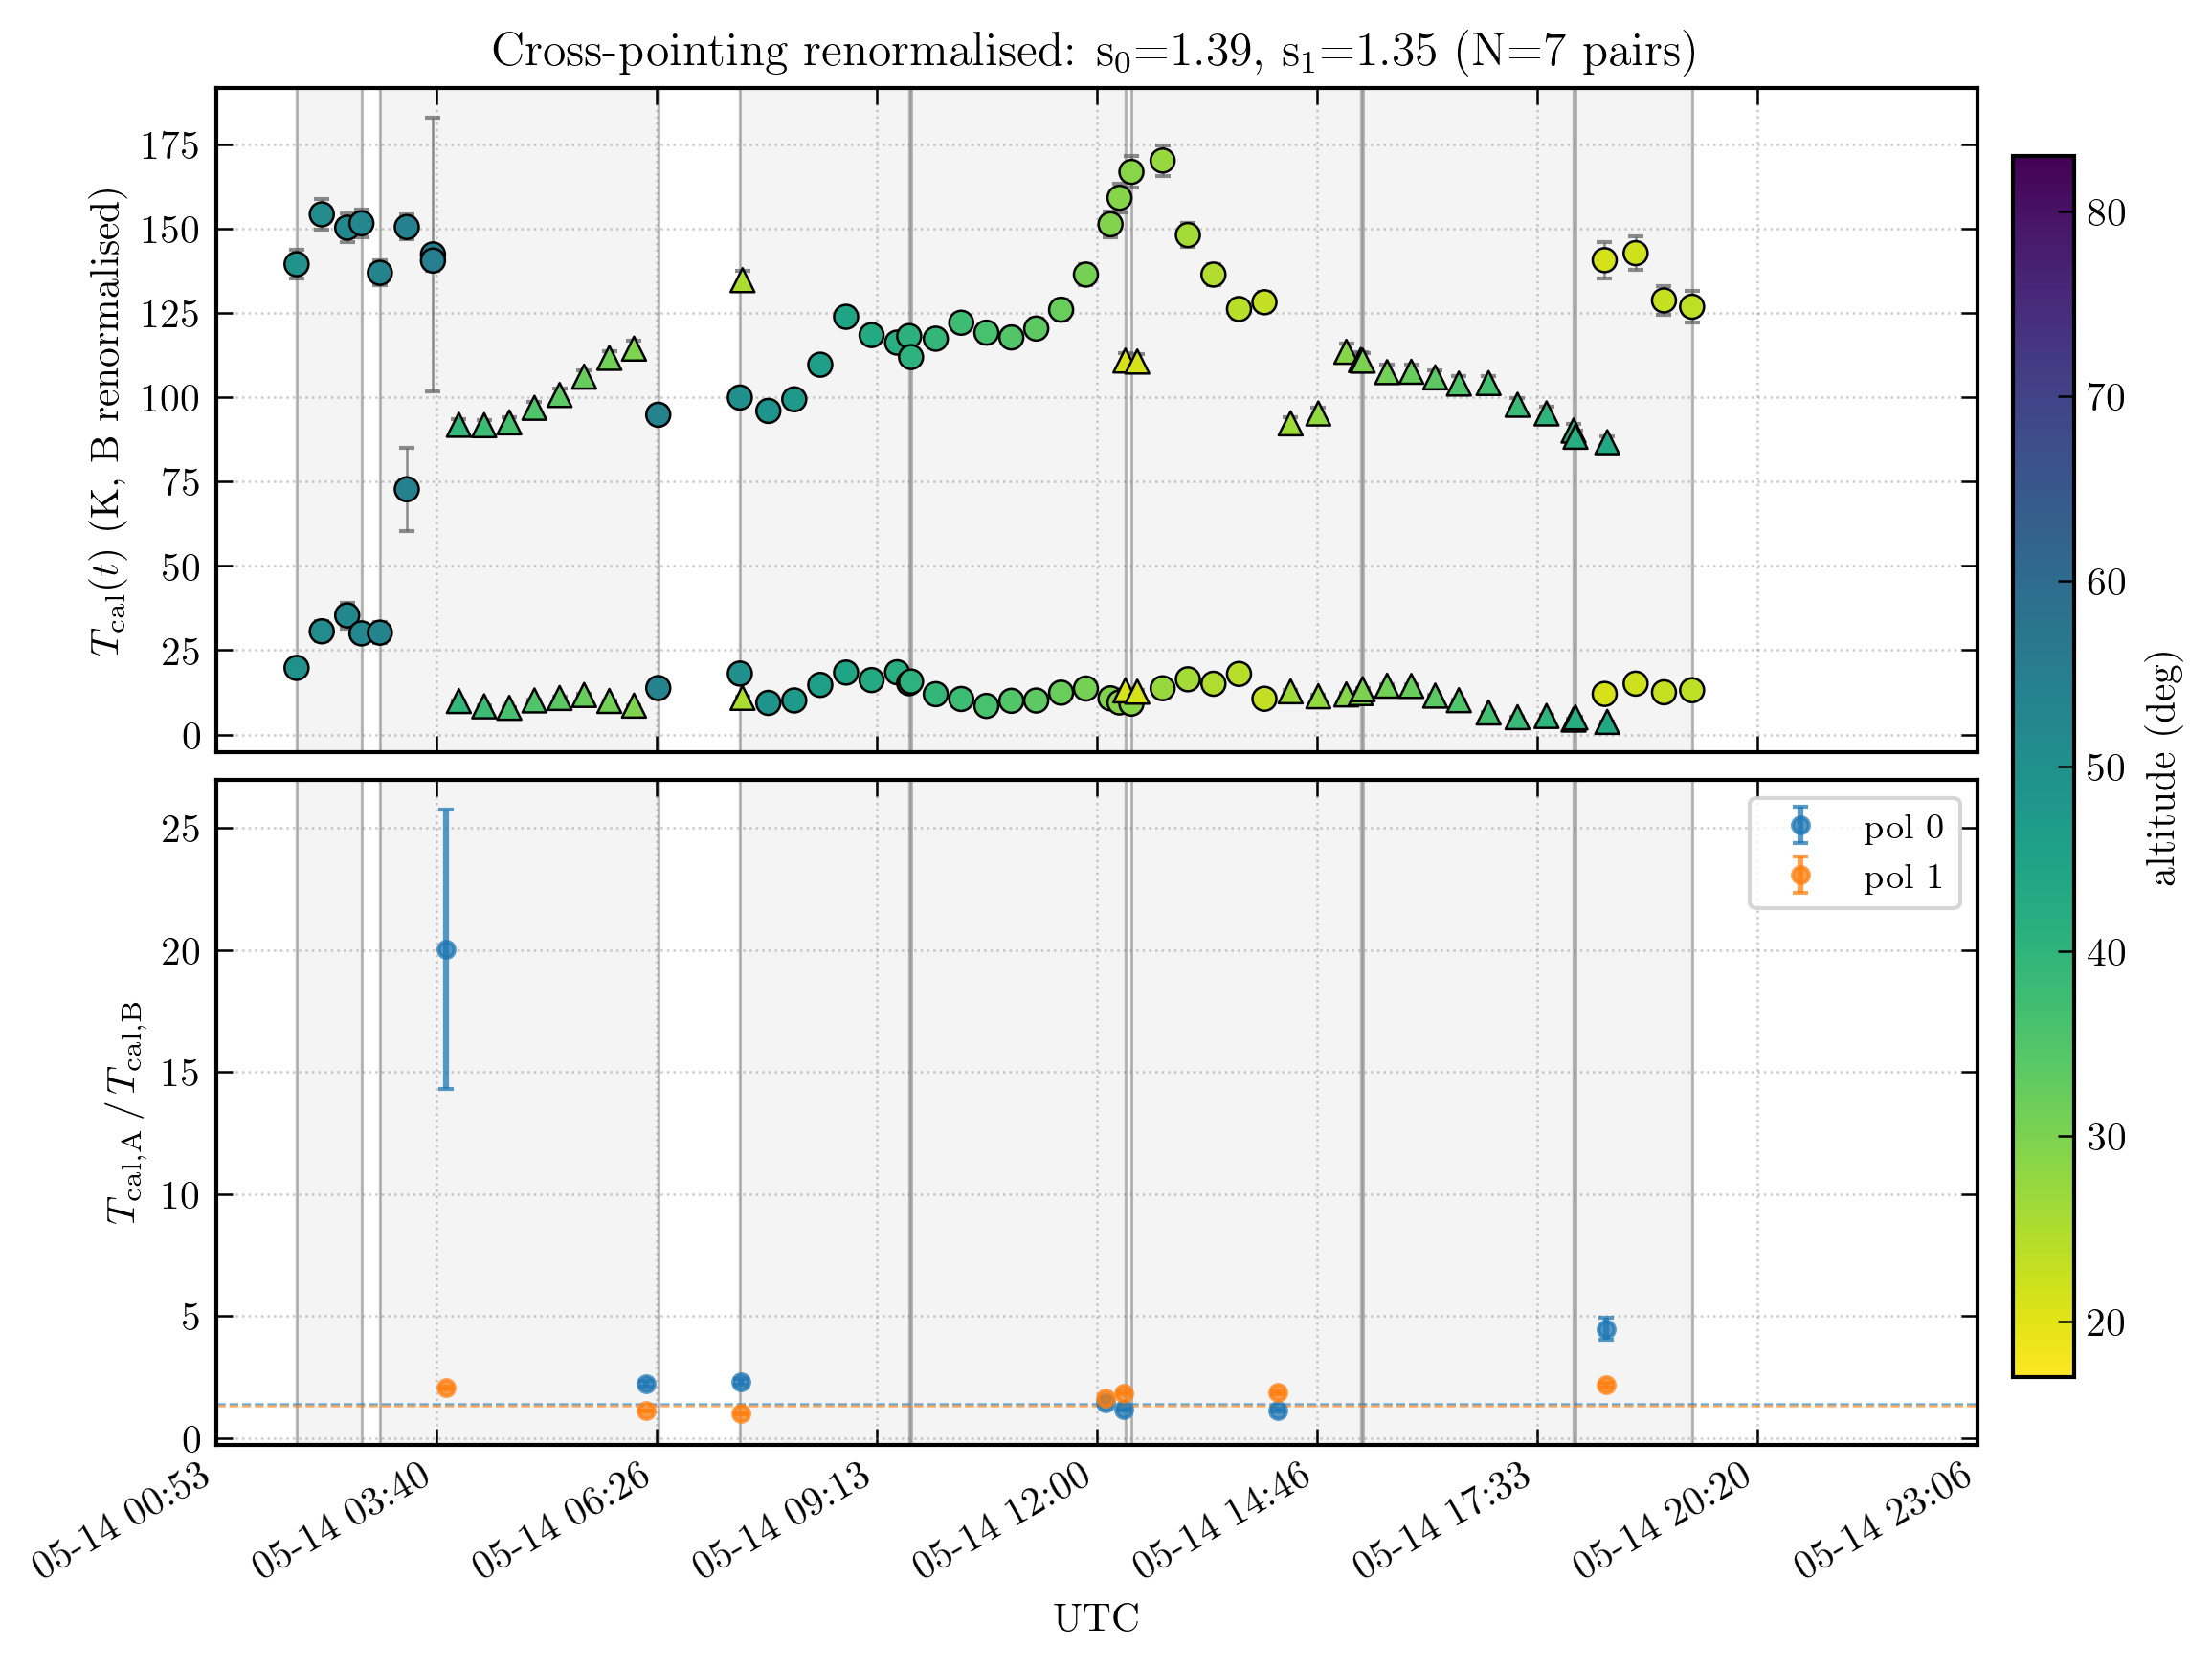

In [15]:
# Top panel: renormalised Tcal(t) tracks overlaid (A unchanged, B x s).
# Bottom panel: pair-wise Tcal_A/Tcal_B ratio vs time -- flat means
# the divergence was a pure constant offset; structured means a real
# time-varying differential.
fig = plt.figure(figsize=(TEXTWIDTH_IN, TEXTWIDTH_IN * 12 / 16),
                 constrained_layout=True)
axes = subpanels(fig, 2, sharex=True)

sc = None
ax = axes[0]
_shade_sessions(ax, session_spans)
for tid, df_pt in zip(pointings, (dfA_s, dfB_renorm)):
    for pol_idx, ls in zip((0, 1), ('-', '--')):
        ax.errorbar(df_pt['t_mid'], df_pt[f'Tcal_pol{pol_idx}'],
                    yerr=df_pt[f'sigma_Tcal_pol{pol_idx}'],
                    fmt='none', ecolor='0.4', elinewidth=LW_FINE,
                    capsize=2, alpha=ALPHA_STANDARD, zorder=2)
        sc = ax.scatter(df_pt['t_mid'], df_pt[f'Tcal_pol{pol_idx}'],
                        c=df_pt['alt'], cmap=cmap,
                        vmin=alt_min, vmax=alt_max,
                        marker=markers[tid], s=SS_STANDARD,
                        edgecolor='k', linewidth=LW_FINE, zorder=3,
                        label=(f'pol {pol_idx}' if tid == pointings[0] else None))
ax.set_ylabel(r'$T_{\rm cal}(t)$ (K, B renormalised)')
ax.set_title(rf'Cross-pointing renormalised: '
             rf's$_{{0}}$={scale[0]:.2f}, s$_{{1}}$={scale[1]:.2f} '
             rf'(N={len(pairs_renorm)} pairs)')

ax = axes[1]
_shade_sessions(ax, session_spans)
for pol_idx, color in zip((0, 1), ('C0', 'C1')):
    ts = np.array(ratio_times[pol_idx])
    rs = np.array([r for r, _ in ratios_per_pol[pol_idx]])
    ss = np.array([s for _, s in ratios_per_pol[pol_idx]])
    if len(ts):
        ax.errorbar(ts, rs, yerr=ss, fmt='o', color=color,
                    markersize=4, capsize=2, alpha=ALPHA_STANDARD,
                    label=f'pol {pol_idx}')
        ax.axhline(scale[pol_idx], color=color, ls='--', lw=LW_FINE,
                   alpha=ALPHA_LIGHT)
ax.set_ylabel(r'$T_{\rm cal,A}\,/\,T_{\rm cal,B}$')
ax.legend(loc='best', frameon=True)

xticks = axes[1].get_xticks()
axes[1].set_xticks(xticks)
axes[1].set_xticklabels(
    [dt.datetime.fromtimestamp(t, dt.UTC).strftime('%m-%d %H:%M')
     for t in xticks],
    rotation=30, ha='right',
)
axes[1].set_xlabel('UTC')

if sc is not None:
    cbar = fig.colorbar(sc, ax=axes, location='right',
                        fraction=0.04, pad=0.02, shrink=0.9)
    cbar.set_label('altitude (deg)')

plt.show()
